# Main Project: Predictive Modelling with Linear Regression

***Anand BR, BATCH: PGPDSBA.O.SEP25.A***

# Problem Statement

## Context

An **over-the-top (OTT) media service** is a media service offered directly to viewers via the internet. The term is most synonymous with subscription-based video-on-demand services that offer access to film and television content, including:

*   Existing series acquired from other producers
*   Original content produced specifically for the service

OTT services are typically accessed via:

*   Websites on personal computers
*   Apps on smartphones and tablets
*   Televisions with integrated Smart TV platforms

Currently, OTT services are at a **nascent stage** but are widely accepted as a trending technology globally. With changing customer behavior—shifting from traditional subscriptions to OTT on-demand video and music—OTT streaming is expected to grow rapidly.

*   **Global OTT market size (2019):** $121.61 billion
*   **Projected size by 2027:** $1,039.03 billion
*   **CAGR (2020–2027):** 29.4%

The shift from television to OTT services is driven by benefits such as:

*   On-demand services
*   Ease of access
*   Better networks and digital connectivity

### Impact of COVID-19

OTT services have seen a surge in demand during the pandemic, with some platforms experiencing:

*   **46% increase** in consumption and subscriber count
*   Viewers seeking fresh content

Innovations and advanced transformations will enable customers to access everything they want in a single space, making OTT platforms increasingly attractive.

***

# Objective

**ShowTime** is an OTT service provider offering a wide variety of content (movies, web shows, etc.). They aim to:

*   Determine **driver variables for first-day content viewership**
*   Take necessary measures to improve viewership on their platform

Possible reasons for decline in viewership include:

*   Fewer people visiting the platform
*   Decreased marketing spend
*   Content timing clashes
*   Weekends and holidays

ShowTime has hired you as a **Data Scientist**, provided data on current content, and asked you to:

*   Analyze the data
*   Build a **linear regression model** to determine driving factors for first-day viewership

***

# Data Description

The dataset contains various factors related to content performance. Below is the **data dictionary**:

| **Variable**         | **Description**                                                                |
| -------------------- | ------------------------------------------------------------------------------ |
| `visitors`           | Average number of visitors (in millions) to the platform in the past week      |
| `ad_impressions`     | Number of ad impressions (in millions) across all ad campaigns for the content |
| `major_sports_event` | Indicator of any major sports event on the day                                 |
| `genre`              | Genre of the content                                                           |
| `dayofweek`          | Day of the release of the content                                              |
| `season`             | Season of the release of the content                                           |
| `views_trailer`      | Number of views (in millions) of the content trailer                           |
| `views_content`      | Number of first-day views (in millions) of the content                         |

***



# **Importing Modules**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set()

# split the data into train and test
from sklearn.model_selection import train_test_split

# to build linear regression_model
import statsmodels.api as sm

# to check model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# to build linear regression_model
from sklearn.linear_model import LinearRegression

# to check model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# to build linear regression_model using statsmodels
import statsmodels.api as sm

# to compute VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

import pprint
import inspect
import warnings
warnings.filterwarnings('ignore')

# **Dataset**

In [2]:
from google.colab import files
import io

try:
    uploaded
except NameError:
    uploaded = files.upload()
data = pd.read_csv(io.BytesIO(uploaded['ottdata.csv']))

Saving ottdata.csv to ottdata.csv


In [3]:
#data = pd.read_csv(io.BytesIO(uploaded['ottdata.csv']))

## Displaying the first few rows of the dataset

**Prompt:** <font size=3 color="blue"> Display first few rows of the dataset.

In [4]:
display(data.head())

,visitors,ad_impressions,major_sports_event,genre,dayofweek,season,views_trailer,views_content
0,1.67,1113.81,0,Horror,Wednesday,Spring,56.70,0.51
1,1.46,1498.41,1,Thriller,Friday,Fall,52.69,0.32
2,1.47,1079.19,1,Thriller,Wednesday,Fall,48.74,0.39
3,1.85,1342.77,1,Sci-Fi,Friday,Fall,49.81,0.44
4,1.46,1498.41,0,Sci-Fi,Sunday,Winter,55.83,0.46


* The dataset contains information about ShowTime's viewership.
* Genre, Season, Major_sports_event, and dayofWeek are categorical columns.
* Dependent field to build predictive model is views_content

## Checking the shape of the dataset

**Prompt:** <font size=3 color="blue">Display the shape of the dataset.

In [5]:
data.shape

(1000, 8)

* The dataset contains information 8 fields about 1000 rows.

## Checking the data types of the columns for the dataset

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   visitors            1000 non-null   float64
 1   ad_impressions      1000 non-null   float64
 2   major_sports_event  1000 non-null   int64  
 3   genre               1000 non-null   object 
 4   dayofweek           1000 non-null   object 
 5   season              1000 non-null   object 
 6   views_trailer       1000 non-null   float64
 7   views_content       1000 non-null   float64
dtypes: float64(4), int64(1), object(3)
memory usage: 62.6+ KB


* There are 5 numeric (*float* and *int* type) and 3 string (*object* type) columns in the data
* The target variable is the `views_content`, which is of *float* type
* major_sports_event eventhoug is inte64, it should be categorical column.

## Statistical summary of the dataset

In [7]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
visitors,1000.0,1.70429,0.231973,1.25,1.5500,1.70,1.830,2.34
ad_impressions,1000.0,1434.71229,289.534834,1010.87,1210.3300,1383.58,1623.670,2424.20
major_sports_event,1000.0,0.40000,0.490143,0.00,0.0000,0.00,1.000,1.00
views_trailer,1000.0,66.91559,35.001080,30.08,50.9475,53.96,57.755,199.92
views_content,1000.0,0.47340,0.105914,0.22,0.4000,0.45,0.520,0.89


In [8]:
data.major_sports_event.value_counts()

,count
major_sports_event,
0,600
1,400


In [9]:
data.major_sports_event = data.major_sports_event.astype('object')

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   visitors            1000 non-null   float64
 1   ad_impressions      1000 non-null   float64
 2   major_sports_event  1000 non-null   object 
 3   genre               1000 non-null   object 
 4   dayofweek           1000 non-null   object 
 5   season              1000 non-null   object 
 6   views_trailer       1000 non-null   float64
 7   views_content       1000 non-null   float64
dtypes: float64(4), object(4)
memory usage: 62.6+ KB


In [11]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
visitors,1000.0,1.70429,0.231973,1.25,1.5500,1.70,1.830,2.34
ad_impressions,1000.0,1434.71229,289.534834,1010.87,1210.3300,1383.58,1623.670,2424.20
views_trailer,1000.0,66.91559,35.001080,30.08,50.9475,53.96,57.755,199.92
views_content,1000.0,0.47340,0.105914,0.22,0.4000,0.45,0.520,0.89


### Description

## 1) `visitors`

*   **Mean:** 1.70M
*   **Median (50%):** 1.70M
*   **Std dev:** 0.232M (low to moderate variability)
*   **Range:** 1.25M → 2.34M
*   **Quartiles:** Q1 1.55M, Q3 1.83M (IQR ≈ 0.28M)

**Interpretation:**  
Visitor levels are fairly stable week-to-week and roughly symmetric around 1.7M. The max (2.34M) is slightly above the outlier threshold (Q3 + 1.5×IQR ≈ 2.25M), indicating a few high-visitor weeks.

***

## 2) `ad_impressions`

*   **Mean:** 1,434.7M
*   **Median:** 1,383.6M
*   **Std dev:** 289.5M (moderate variability)
*   **Range:** 1,010.9M → 2,424.2M
*   **Quartiles:** Q1 1,210.3M, Q3 1,623.7M (IQR ≈ 413.3M)

**Interpretation:**  
Central 50% lies between \~1.21B and \~1.62B impressions. The max (2.42B) is just above the outlier threshold (Q3 + 1.5×IQR ≈ 2.24B), suggesting a few heavy campaigns. Distribution shows mild right skew (mean > median).

***

## 4) `views_trailer`

*   **Mean:** 66.92M
*   **Median:** 53.96M
*   **Std dev:** 35.00M (high variability)
*   **Range:** 30.08M → 199.92M
*   **Quartiles:** Q1 50.95M, Q3 57.76M (IQR ≈ 6.81M)

**Interpretation:**  
Median (≈54M) is well below mean (≈67M), indicating strong right skew with a long tail (viral trailers). Outlier threshold: Q3 + 1.5×IQR ≈ 67.97M → Max (199.92M) is far above this, confirming many high-end outliers.  

***

## 5) `views_content` (first-day views)

*   **Mean:** 0.473M
*   **Median:** 0.450M
*   **Std dev:** 0.106M (moderate variability)
*   **Range:** 0.22M → 0.89M
*   **Quartiles:** Q1 0.40M, Q3 0.52M (IQR ≈ 0.12M)

**Interpretation:**  
First-day views show mild right skew (mean > median). Outlier threshold: Q3 + 1.5×IQR ≈ 0.70M → Max (0.89M) is above this, indicating a set of high-performing launches.  



### Checking for duplicate values

In [12]:
data.duplicated().sum()

np.int64(0)

### Checking for missing values

In [13]:
data.isnull().sum()

,0
visitors,0
ad_impressions,0
major_sports_event,0
genre,0
dayofweek,0
season,0
views_trailer,0
views_content,0


* There are NO MISSING values in many columns.

In [14]:
# creating a copy of the data so that original data remains unchanged
df = data.copy()

# OOPs and Functions

In [15]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [16]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        hue=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [17]:
class UnivariateAnalyzer:
    """
    A class to perform comprehensive univariate analysis on a pandas DataFrame.
    """
    def __init__(self, dataframe: pd.DataFrame):
        """
        Initializes the UnivariateAnalyzer with a pandas DataFrame.
        """
        self.df = dataframe

    def display_data_structure(self):
       """
       Displays the data structure, number of rows columns and data types of the DataFrame.
       """
       print("Data Structure:")
       print("\n------------------------")
       print(f"Number of Rows: {self.df.shape[0]}")
       print("\n------------------------")
       print(f"Number of Columns: {self.df.shape[1]}")
       print("\n------------------------")
       columns = list(self.df.columns)
       print("list of columns:")
       print("\n------------------------")
       pprint.pprint(columns)


    def display_datatypes(self):
        """
        Displays the data types of all columns in the DataFrame.
        """
        print("Data Types:")
        self.df.info()
        print("\n--- Data Type Counts ---")
        print(self.df.dtypes.value_counts())
        print("\n------------------------")

    def display_missing_values(self):
        """
        Calculates and displays the count and percentage of missing values for each column.
        """
        missing_values = self.df.isnull().sum()
        missing_percentage = (missing_values / len(self.df)) * 100
        missing_info = pd.DataFrame({'Count': missing_values, 'Percentage': missing_percentage})
        missing_info = missing_info[missing_info['Count'] > 0].sort_values(by='Count', ascending=False)
        print("\nMissing Values:")
        display(missing_info)

    def display_summary_statistics(self, include: str = 'all'):
        """
        Displays descriptive statistics for numerical and/or categorical columns.
        """
        if include == 'numerical' or include == 'all':
            print("\nSummary Statistics for Numerical Columns:")
            display(self.df.describe())

        if include == 'categorical' or include == 'all':
            print("\nSummary Statistics for Categorical Columns:")
            display(self.df.describe(include='object'))

    def check_data_irregularities(self):
        """
        Checks for potential data irregularities (e.g., inconsistencies in categorical values) across all relevant columns.
        """
        if self.df is not None:
            print("\n--- Checking for Data Irregularities ---")
            for col in self.df.columns:
                if pd.api.types.is_object_dtype(self.df[col]) or pd.api.types.is_categorical_dtype(self.df[col]):
                    print(f"\nUnique values in '{col}':")
                    print(self.df[col].unique())

    def check_column_irregularities(self, column: str):
        """
        Checks for potential data irregularities (e.g., inconsistencies in categorical values) in a specific column.

        Args:
            column (str): The name of the column to check.
        """
        if column not in self.df.columns:
            print(f"Error: Column '{column}' not found in the DataFrame.")
            return
        if pd.api.types.is_object_dtype(self.df[column]) or pd.api.types.is_categorical_dtype(self.df[column]):
            print(f"\n--- Checking for Data Irregularities in '{column}' ---")
            print(f"Unique values in '{column}':")
            print(self.df[column].unique())
        else:
            print(f"Column '{column}' is not a categorical or object type column. Irregularity check skipped.")


    def check_value_counts(self):
        """
        Displays the value counts for each categorical column.
        """
        if self.df is not None:
            print("\n--- Checking Value Counts for Categorical Columns ---")
            for col in self.df.columns:
                if pd.api.types.is_object_dtype(self.df[col]) or pd.api.types.is_categorical_dtype(self.df[col]):
                    print(f"\nValue counts for '{col}': NOT Normalized")
                    print(self.df[col].value_counts())
                    print('*'*50)
                    print(f"\nValue counts for '{col}': WITH Normalized")
                    print('*'*50)
                    print(self.df[col].value_counts(normalize=True))
                    print('*'*50)

    def plot_histogram(self, column: str, bins: int = 10, kde: bool = False):
        """
        Generates a histogram for a numerical column.
        """
        if column not in self.df.columns:
            print(f"Error: Column '{column}' not found in the DataFrame.")
            return
        if not pd.api.types.is_numeric_dtype(self.df[column]):
            print(f"Error: Column '{column}' is not a numerical column. Cannot plot histogram.")
            return

        plt.figure(figsize=(8, 6))
        sns.histplot(data=self.df, x=column, bins=bins, kde=kde)
        plt.title(f'Histogram of {column}')
        plt.xlabel(column)
        plt.ylabel('Frequency')
        plt.show()

    def plot_boxplot(self, column: str, showfliers: bool = True):
        """
        Generates a box plot for a numerical column.

        Args:
            column (str): The name of the numerical column to plot.
            showfliers (bool): Whether to show outliers. Defaults to True.
        """
        if column not in self.df.columns:
            print(f"Error: Column '{column}' not found in the DataFrame.")
            return
        if not pd.api.types.is_numeric_dtype(self.df[column]):
            print(f"Error: Column '{column}' is not a numerical column. Cannot plot box plot.")
            return

        plt.figure(figsize=(8, 6))
        sns.boxplot(data=self.df, x=column, showfliers=showfliers)
        plt.title(f'Box Plot of {column}')
        plt.xlabel(column)
        plt.show()

    def plot_countplot(self, column: str):
        """
        Generates a count plot for a categorical column.

        Args:
            column (str): The name of the categorical column to plot.
        """
        if column not in self.df.columns:
            print(f"Error: Column '{column}' not found in the DataFrame.")
            return
        if not pd.api.types.is_categorical_dtype(self.df[column]) and not pd.api.types.is_object_dtype(self.df[column]):
            print(f"Error: Column '{column}' is not a categorical column. Cannot plot count plot.")
            return


        plt.figure(figsize=(10, 6))
        sns.countplot(data=self.df, x=column)
        plt.title(f'Count Plot of {column}')
        plt.xlabel(column)
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()


    def analyze_column(self, column: str):
        """
        Provides a comprehensive univariate analysis for a specified column.

        Displays data type, missing value information, summary statistics,
        and relevant visualizations (histogram/boxplot for numerical,
        countplot for categorical).

        Args:
            column (str): The name of the column to analyze.
        """
        if column not in self.df.columns:
            print(f"Error: Column '{column}' not found in the DataFrame.")
            return

        print(f"\n--- Analyzing Column: {column} ---")

        # Display data type
        print("\nData Type:")
        print(self.df[column].dtype)

        # Display missing value information
        print("\nMissing Value Information:")
        missing_count = self.df[column].isnull().sum()
        missing_percentage = (missing_count / len(self.df)) * 100
        print(f"Count: {missing_count}, Percentage: {missing_percentage:.3f}%")

        # Check if the column is numerical
        if pd.api.types.is_numeric_dtype(self.df[column]):
            # Display numerical summary statistics
            print("\nNumerical Summary Statistics:")
            display(self.df[column].describe())

            # Generate visualizations
            self.plot_histogram(column, kde=True)
            self.plot_boxplot(column)

        # If not numerical, assume categorical/object type
        elif pd.api.types.is_categorical_dtype(self.df[column]) or pd.api.types.is_object_dtype(self.df[column]):
             # Display categorical summary statistics
            print("\nCategorical Summary Statistics:")
            display(self.df[column].value_counts())
            display(self.df[column].value_counts(normalize=True))


            # Generate visualization
            self.plot_countplot(column)

        else:
            print(f"\nColumn '{column}' is of unhandled data type: {self.df[column].dtype}")

        print(f"\n--- Analysis Complete for Column: {column} ---")

In [18]:
class BivariateAnalyzer:
    """
    A class to perform bivariate analysis on a pandas DataFrame.

    Provides methods to visualize relationships between pairs of columns
    and automatically selects the appropriate analysis based on data types.
    """
    def __init__(self, dataframe: pd.DataFrame):
        """
        Initializes the BivariateAnalyzer with a pandas DataFrame.

        Args:
            dataframe (pd.DataFrame): The DataFrame to analyze.
        """
        self.df = dataframe

    def plot_correlation_matrix(self, figsize: tuple = (10, 8)):
        """
        Calculates and displays the correlation matrix for numerical columns
        with a heatmap visualization.

        Args:
            figsize (tuple): The size of the figure for the heatmap. Defaults to (10, 8).
        """
        # Select numerical columns
        numerical_df = self.df.select_dtypes(include=np.number)

        # Calculate the correlation matrix
        correlation_matrix = numerical_df.corr()

        # Create the heatmap
        plt.figure(figsize=figsize)
        sns.heatmap(correlation_matrix, annot=True, cmap='Spectral', vmin=-1, vmax=1)
        plt.title('Correlation Matrix of Numerical Columns')
        plt.show()

    def plot_numerical_numerical(self, col1: str, col2: str, kind: str, figsize: tuple = (10, 6)):
        """
        Generates a scatter or line plot for two numerical columns.

        Args:
            col1 (str): The name of the first numerical column (x-axis).
            col2 (str): The name of the second numerical column (y-axis).
            kind (str): The type of plot to generate ('scatter' or 'line').
            figsize (tuple): The size of the figure for the plot. Defaults to (10, 6).
        """
        if col1 not in self.df.columns:
            print(f"Error: Column '{col1}' not found in the DataFrame.")
            return
        if col2 not in self.df.columns:
            print(f"Error: Column '{col2}' not found in the DataFrame.")
            return
        if not pd.api.types.is_numeric_dtype(self.df[col1]):
            print(f"Error: Column '{col1}' is not a numerical column. Cannot plot.")
            return
        if not pd.api.types.is_numeric_dtype(self.df[col2]):
            print(f"Error: Column '{col2}' is not a numerical column. Cannot plot.")
            return

        plt.figure(figsize=figsize)

        if kind == 'scatter':
            sns.scatterplot(data=self.df, x=col1, y=col2)
            plt.title(f'Scatter Plot of {col1} vs. {col2}')
        elif kind == 'line':
            sns.lineplot(data=self.df, x=col1, y=col2, ci=None)
            plt.title(f'Line Plot of {col1} vs. {col2}')
        else:
            print(f"Error: Invalid 'kind' specified. Supported values are 'scatter' and 'line'.")
            return

        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()


    def plot_numerical_categorical(self, numerical_col: str, categorical_col: str, kind: str, figsize: tuple = (10, 6)):
        """
        Generates a box plot or violin plot for a numerical column across categories
        of a categorical column.

        Args:
            numerical_col (str): The name of the numerical column (y-axis).
            categorical_col (str): The name of the categorical column (x-axis).
            kind (str): The type of plot to generate ('boxplot' or 'violinplot').
            figsize (tuple): The size of the figure for the plot. Defaults to (10, 6).
        """
        if numerical_col not in self.df.columns:
            print(f"Error: Numerical column '{numerical_col}' not found in the DataFrame.")
            return
        if categorical_col not in self.df.columns:
            print(f"Error: Categorical column '{categorical_col}' not found in the DataFrame.")
            return
        if not pd.api.types.is_numeric_dtype(self.df[numerical_col]):
            print(f"Error: Column '{numerical_col}' is not a numerical column. Cannot plot.")
            return
        if not pd.api.types.is_categorical_dtype(self.df[categorical_col]) and not pd.api.types.is_object_dtype(self.df[categorical_col]):
            print(f"Error: Column '{categorical_col}' is not a categorical column. Cannot plot.")
            return

        plt.figure(figsize=figsize)

        if kind == 'boxplot':
            sns.boxplot(data=self.df, x=categorical_col, y=numerical_col, showfliers=False)
            plt.title(f'Box Plot of {numerical_col} by {categorical_col}')
        elif kind == 'violinplot':
            sns.violinplot(data=self.df, x=categorical_col, y=numerical_col)
            plt.title(f'Violin Plot of {numerical_col} by {categorical_col}')
        else:
            print(f"Error: Invalid 'kind' specified. Supported values are 'boxplot' and 'violinplot'.")
            return

        plt.xlabel(categorical_col)
        plt.ylabel(numerical_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

    def analyze_categorical_categorical(self, cat_col1: str, cat_col2: str, figsize: tuple = (10, 8)):
        """
        Analyzes the relationship between two categorical variables.

        Displays a contingency table and generates a heatmap visualization.

        Args:
            cat_col1 (str): The name of the first categorical column.
            cat_col2 (str): The name of the second categorical column.
            figsize (tuple): The size of the figure for the heatmap. Defaults to (10, 8).
        """
        if cat_col1 not in self.df.columns:
            print(f"Error: Column '{cat_col1}' not found in the DataFrame.")
            return
        if cat_col2 not in self.df.columns:
            print(f"Error: Column '{cat_col2}' not found in the DataFrame.")
            return
        if not (pd.api.types.is_categorical_dtype(self.df[cat_col1]) or pd.api.types.is_object_dtype(self.df[cat_col1])):
            print(f"Error: Column '{cat_col1}' is not a categorical or object column. Cannot analyze.")
            return
        if not (pd.api.types.is_categorical_dtype(self.df[cat_col2]) or pd.api.types.is_object_dtype(self.df[cat_col2])):
            print(f"Error: Column '{cat_col2}' is not a categorical or object column. Cannot analyze.")
            return

        print(f"\n--- Analyzing Relationship between {cat_col1} and {cat_col2} ---")

        # Create and display contingency table
        contingency_table = pd.crosstab(self.df[cat_col1], self.df[cat_col2])
        print("\nContingency Table:")
        display(contingency_table)

        # Create heatmap visualization
        plt.figure(figsize=figsize)
        sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlGnBu')
        plt.title(f'Heatmap of {cat_col1} vs. {cat_col2}')
        plt.xlabel(cat_col2)
        plt.ylabel(cat_col1)
        plt.show()

        print(f"\n--- Analysis Complete for {cat_col1} and {cat_col2} ---")

    def analyze_bivariate(self, col1: str, col2: str):
        """
        Performs relevant bivariate analysis based on the data types of two columns.

        Automatically determines if the columns are numerical or categorical
        and calls the appropriate plotting or analysis method.

        Args:
            col1 (str): The name of the first column to analyze.
            col2 (str): The name of the second column to analyze.
        """
        if col1 not in self.df.columns:
            print(f"Error: Column '{col1}' not found in the DataFrame.")
            return
        if col2 not in self.df.columns:
            print(f"Error: Column '{col2}' not found in the DataFrame.")
            return

        col1_is_numeric = pd.api.types.is_numeric_dtype(self.df[col1])
        col2_is_numeric = pd.api.types.is_numeric_dtype(self.df[col2])
        col1_is_categorical = pd.api.types.is_categorical_dtype(self.df[col1]) or pd.api.types.is_object_dtype(self.df[col1])
        col2_is_categorical = pd.api.types.is_categorical_dtype(self.df[col2]) or pd.api.types.is_object_dtype(self.df[col2])

        if col1_is_numeric and col2_is_numeric:
            print(f"\nAnalyzing numerical-numerical relationship between {col1} and {col2}")
            self.plot_numerical_numerical(col1, col2, kind='scatter')
            # Optional: self.plot_numerical_numerical(col1, col2, kind='line')
        elif (col1_is_numeric and col2_is_categorical):
             print(f"\nAnalyzing numerical-categorical relationship between {col1} and {col2}")
             self.plot_numerical_categorical(col1, col2, kind='boxplot')
             # Optional: self.plot_numerical_categorical(col1, col2, kind='violinplot')
        elif (col1_is_categorical and col2_is_numeric):
             print(f"\nAnalyzing numerical-categorical relationship between {col2} and {col1}")
             self.plot_numerical_categorical(col2, col1, kind='boxplot')
             # Optional: self.plot_numerical_categorical(col2, col1, kind='violinplot')
        elif col1_is_categorical and col2_is_categorical:
            print(f"\nAnalyzing categorical-categorical relationship between {col1} and {col2}")
            self.analyze_categorical_categorical(col1, col2)
        else:
            print(f"\nBivariate analysis for data types of '{col1}' ({self.df[col1].dtype}) and '{col2}' ({self.df[col2].dtype}) is not currently supported.")

In [19]:
methods = inspect.getmembers(UnivariateAnalyzer, predicate=inspect.isfunction)
print("Methods in UnivariateAnalyzer class:")
for name, method in methods:
    print(f"- {name}")

Methods in UnivariateAnalyzer class:
- __init__
- analyze_column
- check_column_irregularities
- check_data_irregularities
- check_value_counts
- display_data_structure
- display_datatypes
- display_missing_values
- display_summary_statistics
- plot_boxplot
- plot_countplot
- plot_histogram


In [20]:
methods = inspect.getmembers(BivariateAnalyzer, predicate=inspect.isfunction)
print("Methods in BivariateAnalyzer class:")
for name, method in methods:
    print(f"- {name}")

Methods in BivariateAnalyzer class:
- __init__
- analyze_bivariate
- analyze_categorical_categorical
- plot_correlation_matrix
- plot_numerical_categorical
- plot_numerical_numerical


# EDA

## Univariate Analysis

In [21]:
analyzer = UnivariateAnalyzer(df)

In [22]:
analyzer.display_data_structure()

Data Structure:

------------------------
Number of Rows: 1000

------------------------
Number of Columns: 8

------------------------
list of columns:

------------------------
['visitors',
 'ad_impressions',
 'major_sports_event',
 'genre',
 'dayofweek',
 'season',
 'views_trailer',
 'views_content']


In [23]:
analyzer.display_datatypes()

Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   visitors            1000 non-null   float64
 1   ad_impressions      1000 non-null   float64
 2   major_sports_event  1000 non-null   object 
 3   genre               1000 non-null   object 
 4   dayofweek           1000 non-null   object 
 5   season              1000 non-null   object 
 6   views_trailer       1000 non-null   float64
 7   views_content       1000 non-null   float64
dtypes: float64(4), object(4)
memory usage: 62.6+ KB

--- Data Type Counts ---
float64    4
object     4
Name: count, dtype: int64

------------------------


In [24]:
analyzer.display_missing_values()


Missing Values:


,Count,Percentage


In [25]:
analyzer.check_data_irregularities()


--- Checking for Data Irregularities ---

Unique values in 'major_sports_event':
[0 1]

Unique values in 'genre':
['Horror' 'Thriller' 'Sci-Fi' 'Others' 'Drama' 'Action' 'Comedy' 'Romance']

Unique values in 'dayofweek':
['Wednesday' 'Friday' 'Sunday' 'Thursday' 'Monday' 'Saturday' 'Tuesday']

Unique values in 'season':
['Spring' 'Fall' 'Winter' 'Summer']


In [26]:
analyzer.check_value_counts()


--- Checking Value Counts for Categorical Columns ---

Value counts for 'major_sports_event': NOT Normalized
major_sports_event
0    600
1    400
Name: count, dtype: int64
**************************************************

Value counts for 'major_sports_event': WITH Normalized
**************************************************
major_sports_event
0    0.6
1    0.4
Name: proportion, dtype: float64
**************************************************

Value counts for 'genre': NOT Normalized
genre
Others      255
Comedy      114
Thriller    113
Drama       109
Romance     105
Sci-Fi      102
Horror      101
Action      101
Name: count, dtype: int64
**************************************************

Value counts for 'genre': WITH Normalized
**************************************************
genre
Others      0.255
Comedy      0.114
Thriller    0.113
Drama       0.109
Romance     0.105
Sci-Fi      0.102
Horror      0.101
Action      0.101
Name: proportion, dtype: float64
******************

In [27]:
analyzer.display_summary_statistics()


Summary Statistics for Numerical Columns:


,visitors,ad_impressions,views_trailer,views_content
count,1000.000000,1000.000000,1000.00000,1000.000000
mean,1.704290,1434.712290,66.91559,0.473400
std,0.231973,289.534834,35.00108,0.105914
min,1.250000,1010.870000,30.08000,0.220000
25%,1.550000,1210.330000,50.94750,0.400000
50%,1.700000,1383.580000,53.96000,0.450000
75%,1.830000,1623.670000,57.75500,0.520000
max,2.340000,2424.200000,199.92000,0.890000



Summary Statistics for Categorical Columns:


,major_sports_event,genre,dayofweek,season
count,1000,1000,1000,1000
unique,2,8,7,4
top,0,Others,Friday,Winter
freq,600,255,369,257



--- Analyzing Column: visitors ---

Data Type:
float64

Missing Value Information:
Count: 0, Percentage: 0.000%

Numerical Summary Statistics:


,visitors
count,1000.000000
mean,1.704290
std,0.231973
min,1.250000
25%,1.550000
50%,1.700000
75%,1.830000
max,2.340000


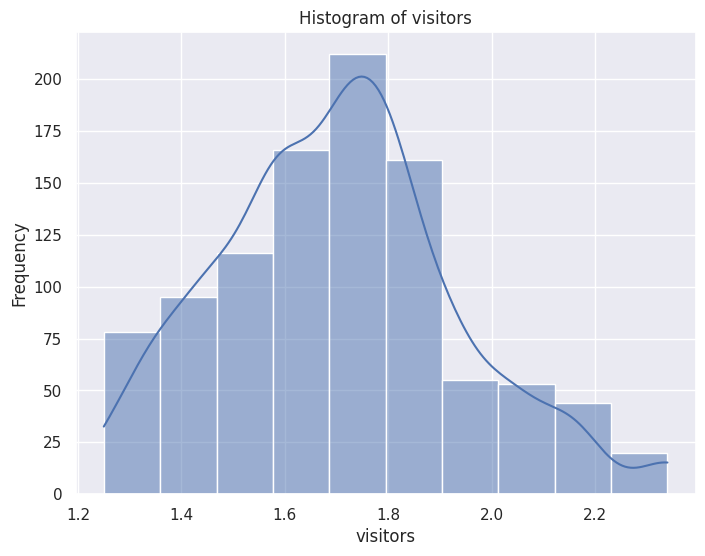

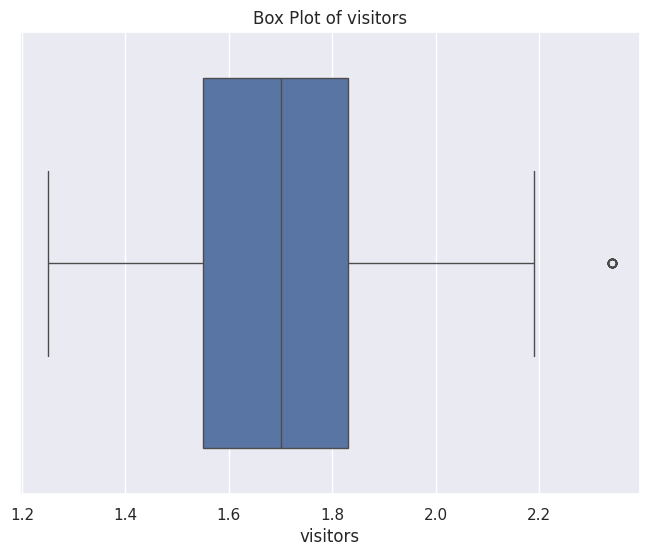


--- Analysis Complete for Column: visitors ---

--- Analyzing Column: ad_impressions ---

Data Type:
float64

Missing Value Information:
Count: 0, Percentage: 0.000%

Numerical Summary Statistics:


,ad_impressions
count,1000.000000
mean,1434.712290
std,289.534834
min,1010.870000
25%,1210.330000
50%,1383.580000
75%,1623.670000
max,2424.200000


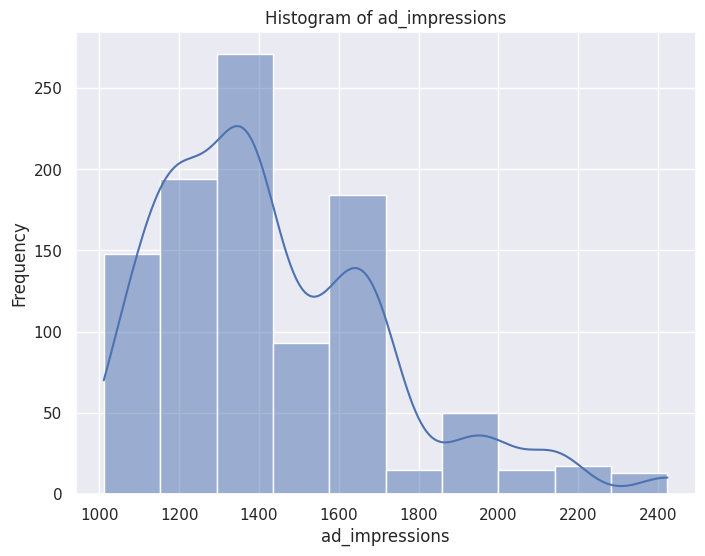

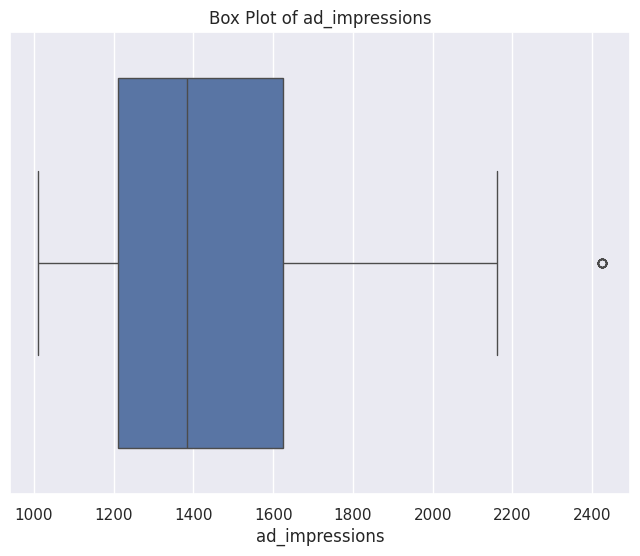


--- Analysis Complete for Column: ad_impressions ---

--- Analyzing Column: major_sports_event ---

Data Type:
object

Missing Value Information:
Count: 0, Percentage: 0.000%

Categorical Summary Statistics:


,count
major_sports_event,
0,600
1,400


,proportion
major_sports_event,
0,0.6
1,0.4


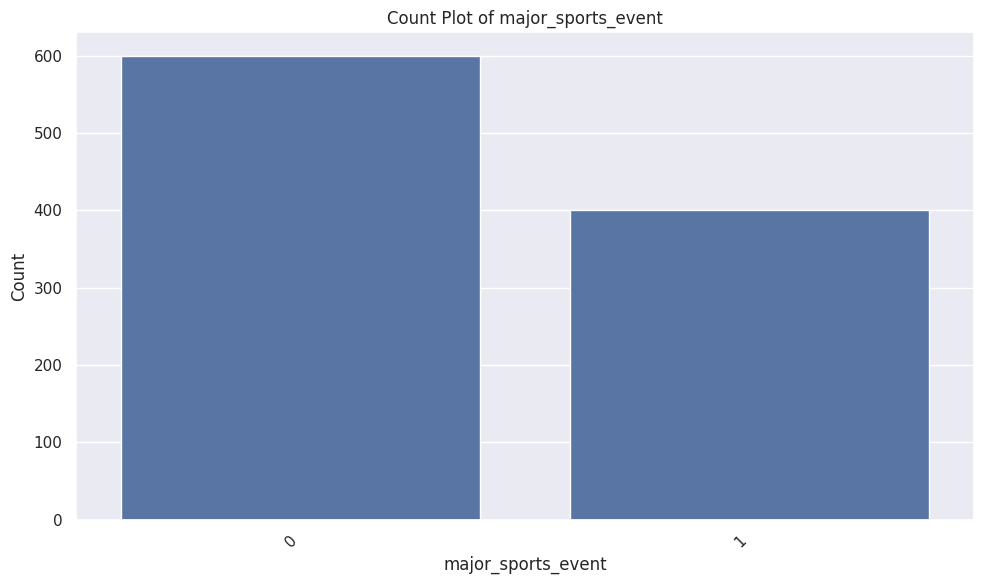


--- Analysis Complete for Column: major_sports_event ---

--- Analyzing Column: genre ---

Data Type:
object

Missing Value Information:
Count: 0, Percentage: 0.000%

Categorical Summary Statistics:


,count
genre,
Others,255
Comedy,114
Thriller,113
Drama,109
Romance,105
Sci-Fi,102
Horror,101
Action,101


,proportion
genre,
Others,0.255
Comedy,0.114
Thriller,0.113
Drama,0.109
Romance,0.105
Sci-Fi,0.102
Horror,0.101
Action,0.101


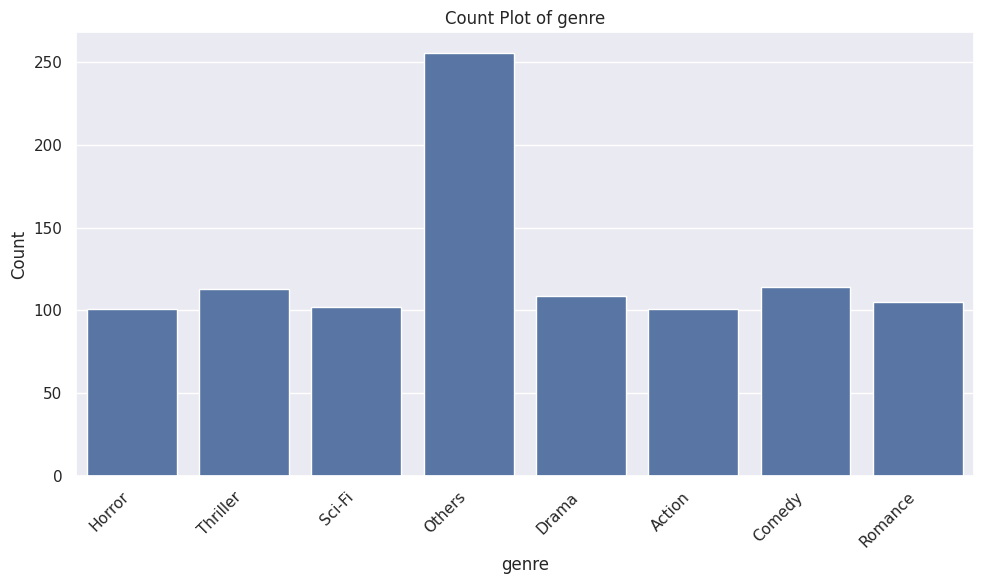


--- Analysis Complete for Column: genre ---

--- Analyzing Column: dayofweek ---

Data Type:
object

Missing Value Information:
Count: 0, Percentage: 0.000%

Categorical Summary Statistics:


,count
dayofweek,
Friday,369
Wednesday,332
Thursday,97
Saturday,88
Sunday,67
Monday,24
Tuesday,23


,proportion
dayofweek,
Friday,0.369
Wednesday,0.332
Thursday,0.097
Saturday,0.088
Sunday,0.067
Monday,0.024
Tuesday,0.023


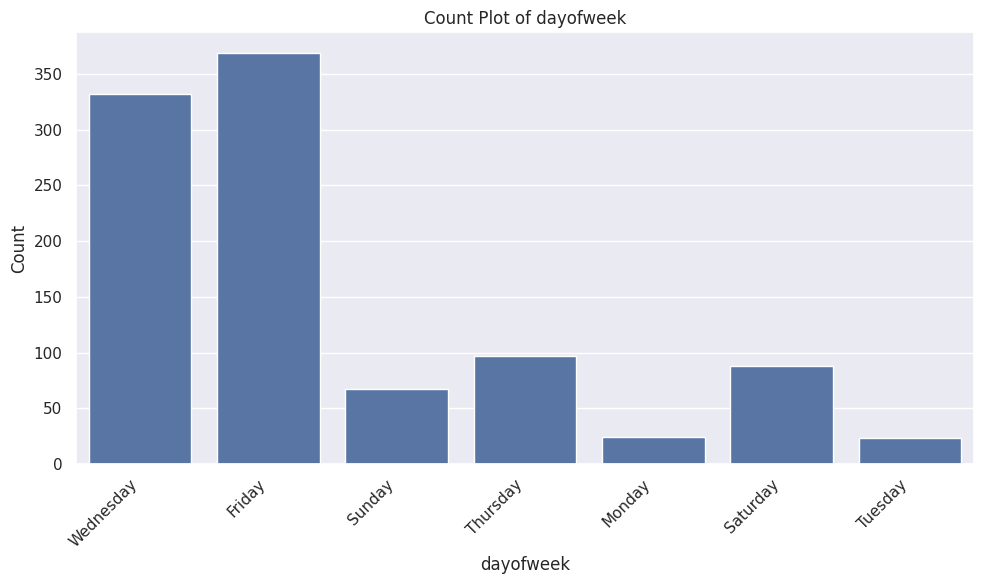


--- Analysis Complete for Column: dayofweek ---

--- Analyzing Column: season ---

Data Type:
object

Missing Value Information:
Count: 0, Percentage: 0.000%

Categorical Summary Statistics:


,count
season,
Winter,257
Fall,252
Spring,247
Summer,244


,proportion
season,
Winter,0.257
Fall,0.252
Spring,0.247
Summer,0.244


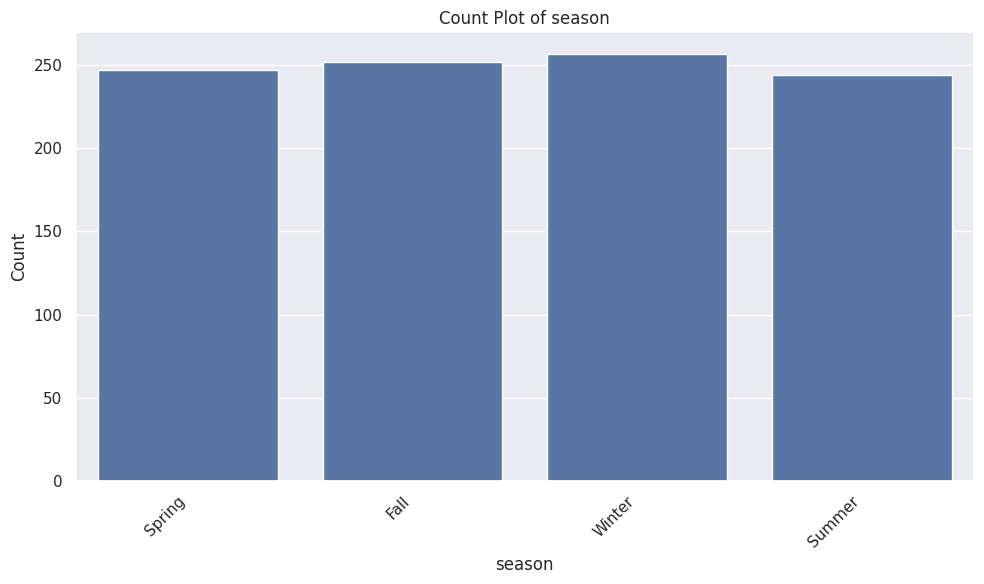


--- Analysis Complete for Column: season ---

--- Analyzing Column: views_trailer ---

Data Type:
float64

Missing Value Information:
Count: 0, Percentage: 0.000%

Numerical Summary Statistics:


,views_trailer
count,1000.00000
mean,66.91559
std,35.00108
min,30.08000
25%,50.94750
50%,53.96000
75%,57.75500
max,199.92000


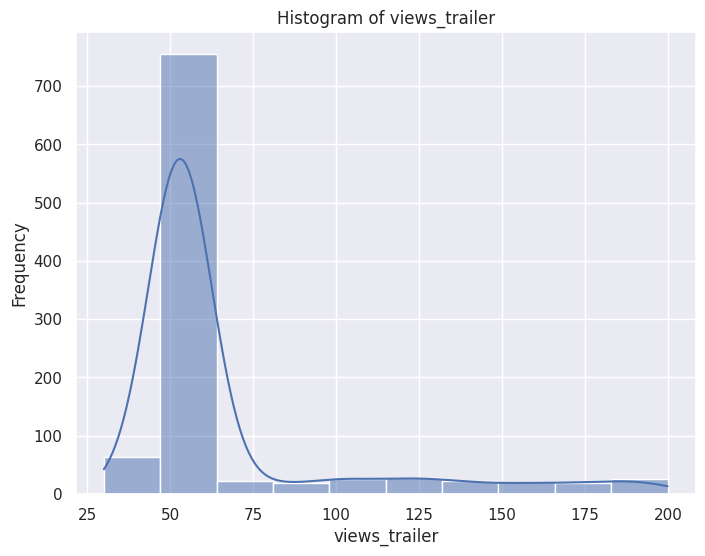

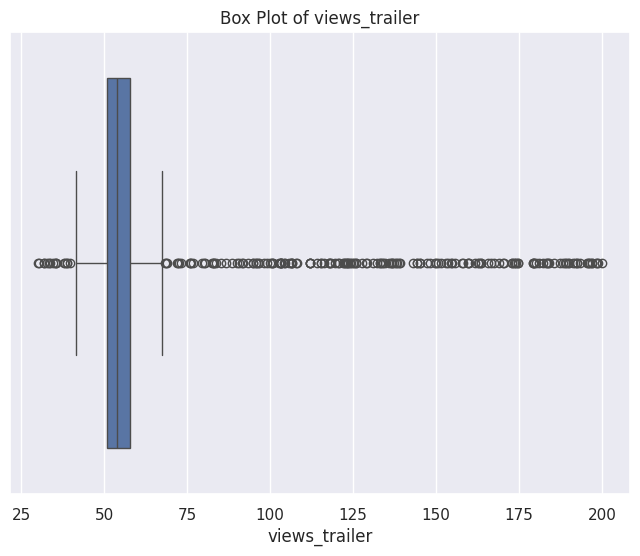


--- Analysis Complete for Column: views_trailer ---

--- Analyzing Column: views_content ---

Data Type:
float64

Missing Value Information:
Count: 0, Percentage: 0.000%

Numerical Summary Statistics:


,views_content
count,1000.000000
mean,0.473400
std,0.105914
min,0.220000
25%,0.400000
50%,0.450000
75%,0.520000
max,0.890000


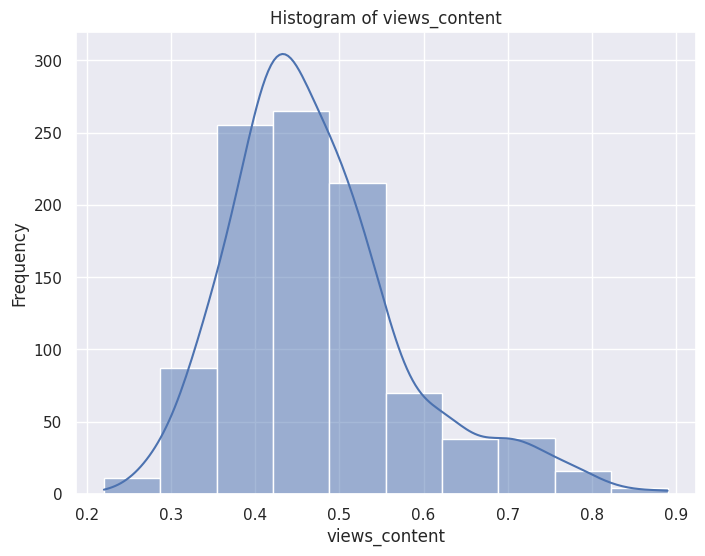

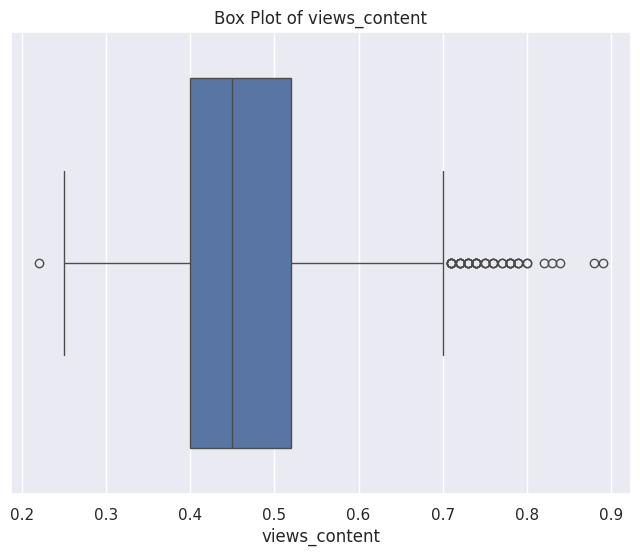


--- Analysis Complete for Column: views_content ---


In [28]:
for i in df.columns:
  analyzer.analyze_column(i)

### Univariate Analysis: Observations and Insights

## 1) `visitors`
*   **Mean:** 1.70M
*   **Median (50%):** 1.70M
*   **Std dev:** 0.232M (low to moderate variability)
*   **Range:** 1.25M → 2.34M
*   **Quartiles:** Q1 1.55M, Q3 1.83M (IQR ≈ 0.28M)

**Interpretation:**  
Visitor levels are fairly stable week-to-week and roughly symmetric around 1.7M. The max (2.34M) is slightly above the outlier threshold (Q3 + 1.5×IQR ≈ 2.25M), indicating a few high-visitor weeks.

***

## 2) `ad_impressions`
*   **Mean:** 1,434.7M
*   **Median:** 1,383.6M
*   **Std dev:** 289.5M (moderate variability)
*   **Range:** 1,010.9M → 2,424.2M
*   **Quartiles:** Q1 1,210.3M, Q3 1,623.7M (IQR ≈ 413.3M)

**Interpretation:**  
Central 50% lies between ~1.21B and ~1.62B impressions. The max (2.42B) is just above the outlier threshold (Q3 + 1.5×IQR ≈ 2.24B), suggesting a few heavy campaigns. Distribution shows mild right skew (mean > median).

***

## 3) `major_sports_event`
*   **Value Counts:** 0 (600 entries), 1 (400 entries)
*   **Percentage:** No major sports event (60%), Major sports event (40%)

**Interpretation:**
Approximately 40% of the content releases occurred on a day when a major sports event was taking place.

***

## 4) `genre`
*   **Value Counts:**
    *   Others: 255 (25.5%)
    *   Comedy: 114 (11.4%)
    *   Thriller: 113 (11.3%)
    *   Drama: 109 (10.9%)
    *   Romance: 105 (10.5%)
    *   Sci-Fi: 102 (10.2%)
    *   Horror: 101 (10.1%)
    *   Action: 101 (10.1%)

**Interpretation:**
'Others' is the most prevalent genre. The remaining genres are distributed fairly evenly, each accounting for approximately 10-11% of the dataset.

***

## 5) `dayofweek`
*   **Value Counts:**
    *   Friday: 369 (36.9%)
    *   Wednesday: 332 (33.2%)
    *   Thursday: 97 (9.7%)
    *   Saturday: 88 (8.8%)
    *   Sunday: 67 (6.7%)
    *   Monday: 24 (2.4%)
    *   Tuesday: 23 (2.3%)

**Interpretation:**
Content is primarily released on Fridays and Wednesdays, which together account for over 70% of all releases. Mondays and Tuesdays have significantly fewer releases.

***

## 6) `season`
*   **Value Counts:**
    *   Winter: 257 (25.7%)
    *   Fall: 252 (25.2%)
    *   Spring: 247 (24.7%)
    *   Summer: 244 (24.4%)

**Interpretation:**
Content releases are almost perfectly balanced across all four seasons, with each season accounting for approximately 24-26% of the data.

***

## 7) `views_trailer`
*   **Mean:** 66.92M
*   **Median:** 53.96M
*   **Std dev:** 35.00M (high variability)
*   **Range:** 30.08M → 199.92M
*   **Quartiles:** Q1 50.95M, Q3 57.76M (IQR ≈ 6.81M)

**Interpretation:**  
Median (≈54M) is well below mean (≈67M), indicating strong right skew with a long tail (viral trailers). Outlier threshold: Q3 + 1.5×IQR ≈ 67.97M → Max (199.92M) is far above this, confirming many high-end outliers.

***

## 8) `views_content` (first-day views) - Target Variable
*   **Mean:** 0.473M
*   **Median:** 0.450M
*   **Std dev:** 0.106M (moderate variability)
*   **Range:** 0.22M → 0.89M
*   **Quartiles:** Q1 0.40M, Q3 0.52M (IQR ≈ 0.12M)

**Interpretation:**  
First-day views show mild right skew (mean > median). Outlier threshold: Q3 + 1.5×IQR ≈ 0.70M → Max (0.89M) is above this, indicating a set of high-performing launches.

## Bivariate analysis

In [29]:
bivariate_analyzer = BivariateAnalyzer(df)

In [30]:
# SPlit the columns to 2 List , categorical and Numerical
cat , nums = [], []
for i in df.columns:
    if df[i].dtypes != 'object':
        nums.append(i)
    else:
        cat.append(i)
print(cat)
print(nums)

['major_sports_event', 'genre', 'dayofweek', 'season']
['visitors', 'ad_impressions', 'views_trailer', 'views_content']


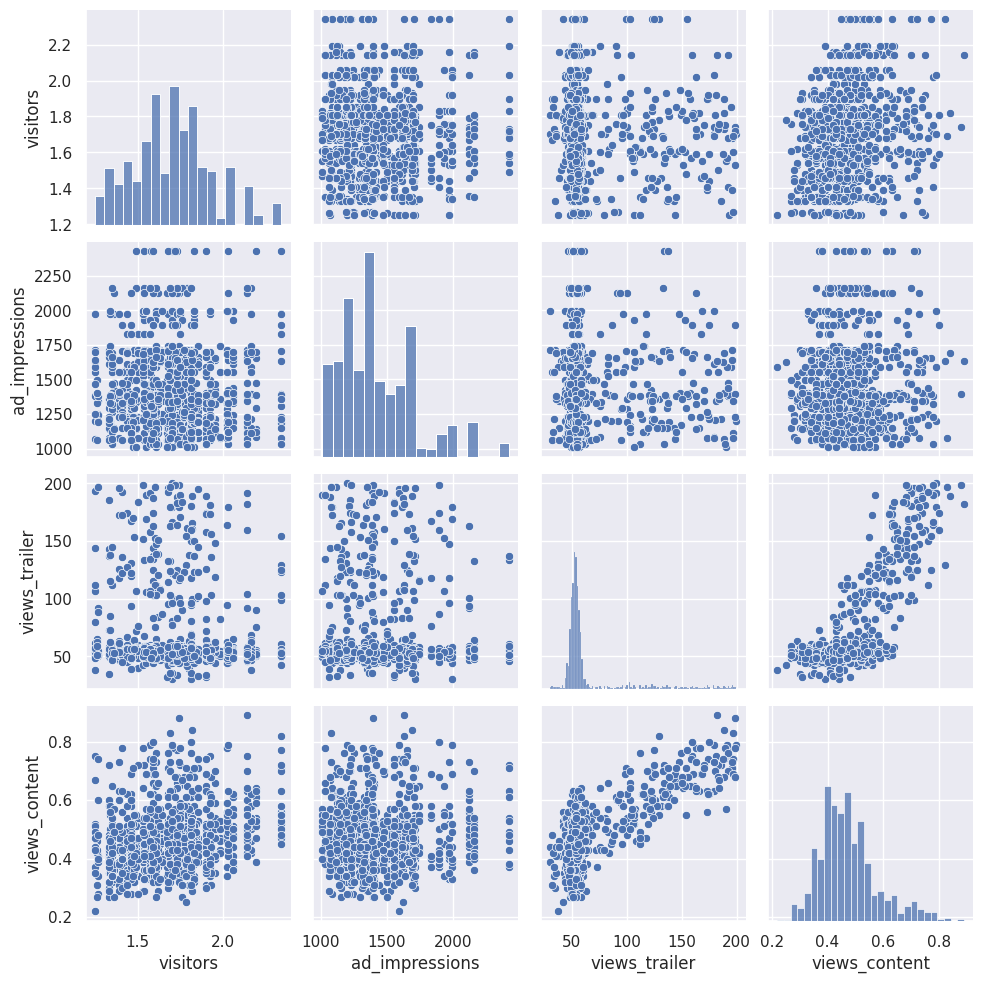

In [31]:
sns.pairplot(df[nums])

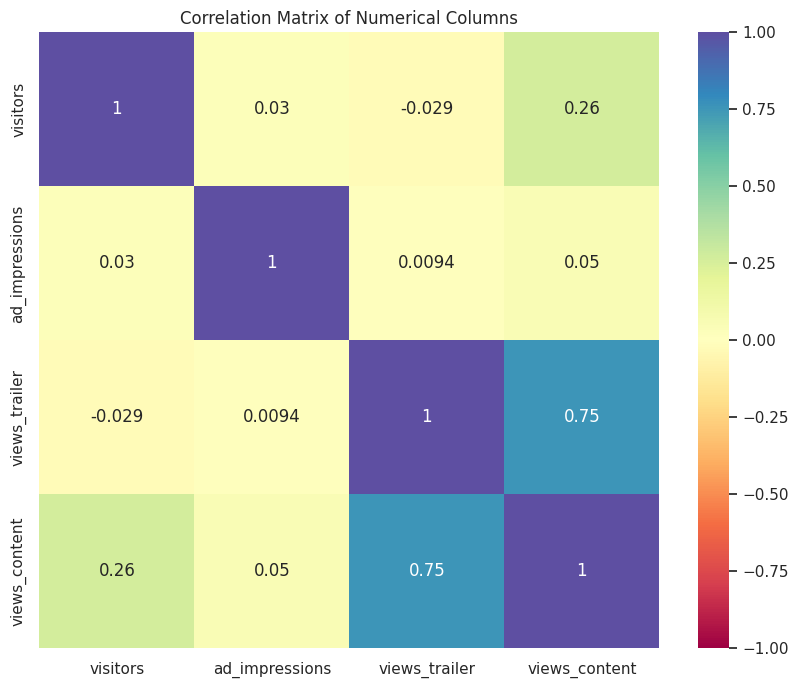

In [32]:
bivariate_analyzer.plot_correlation_matrix()


### Insights

- There are strong correlations with the target variable **`views_content`**.
- **`views_trailer`** is likely to show a strong positive correlation with `views_content`, as more trailer views often translate to more initial content views.
- **`visitors`** and **`ad_impressions`** are also expected to have positive correlations with `views_content`, indicating that higher platform traffic and more advertising generally lead to better first-day viewership.


**Exploring Relationships between Categorical and Numerical Variables**

Analyzing relationship between major_sports_event and visitors


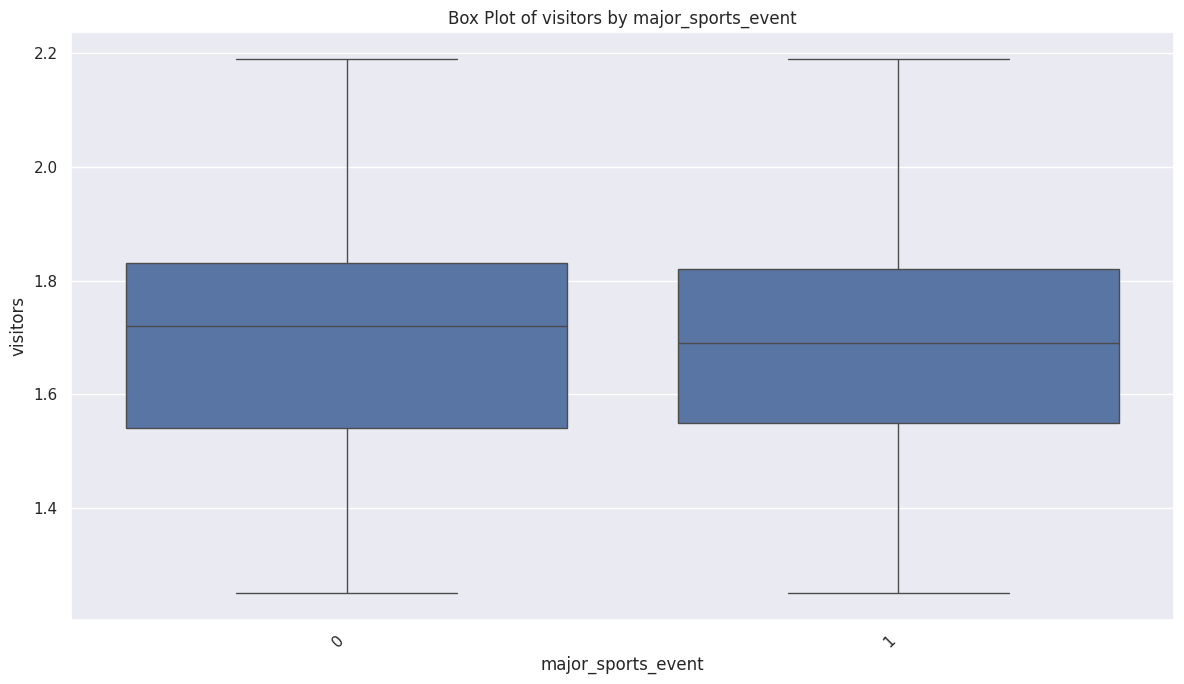

Analyzing relationship between major_sports_event and ad_impressions


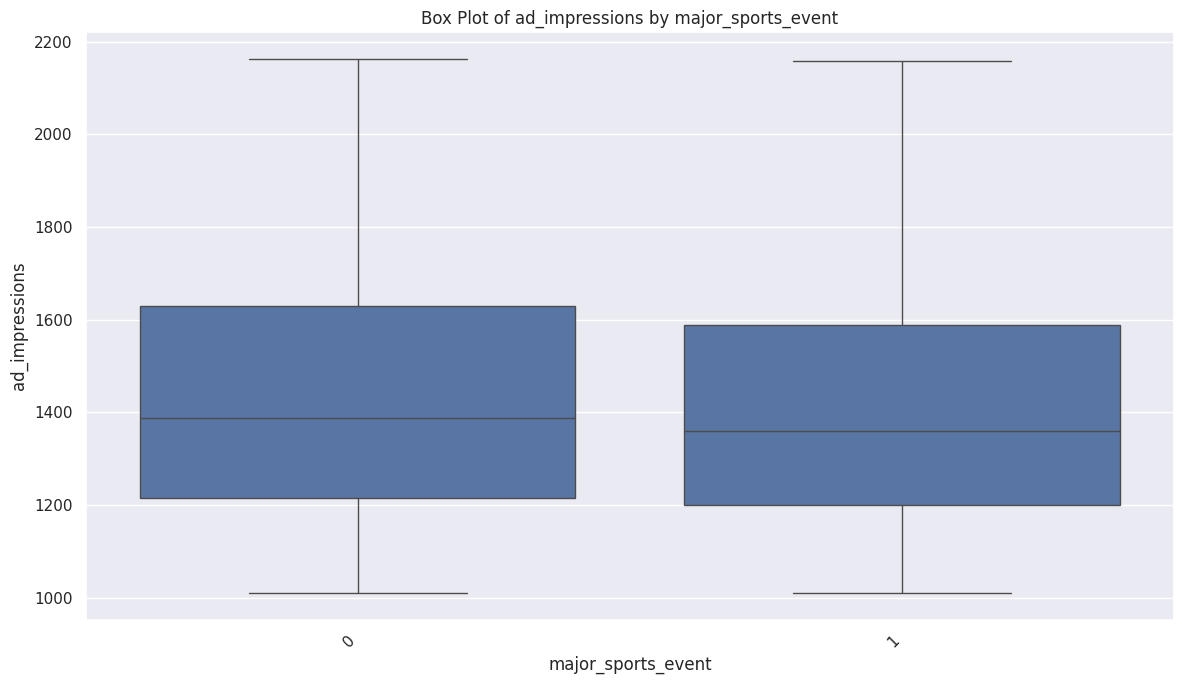

Analyzing relationship between major_sports_event and views_trailer


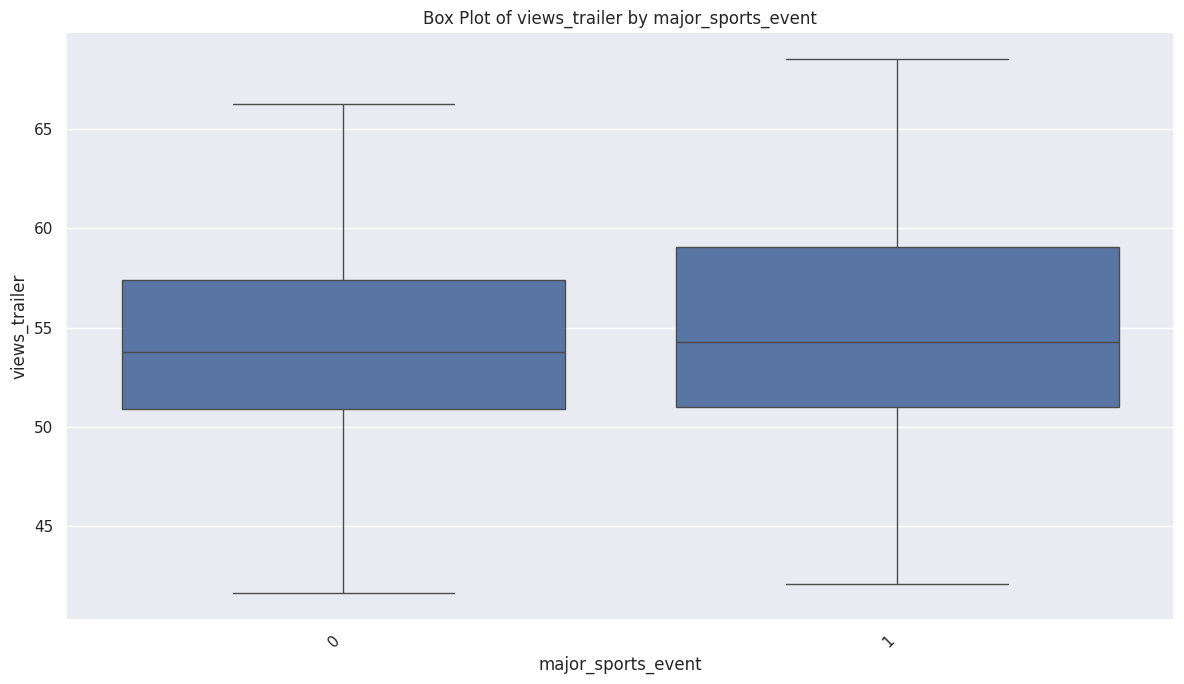

Analyzing relationship between major_sports_event and views_content


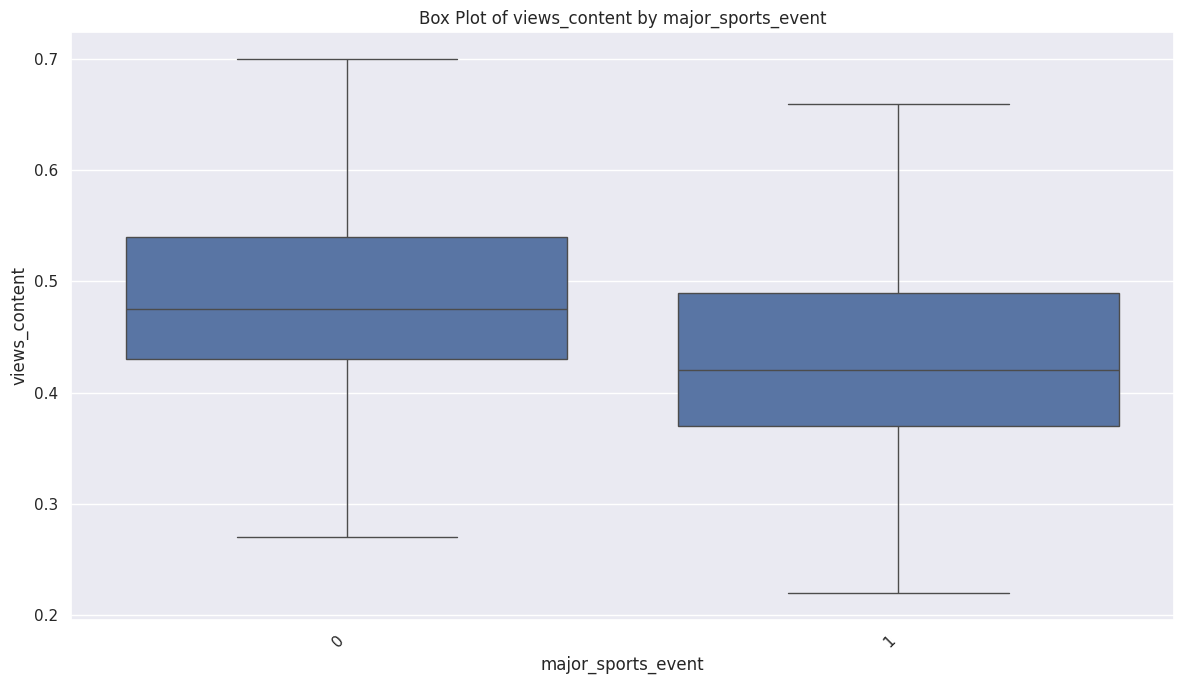

Analyzing relationship between genre and visitors


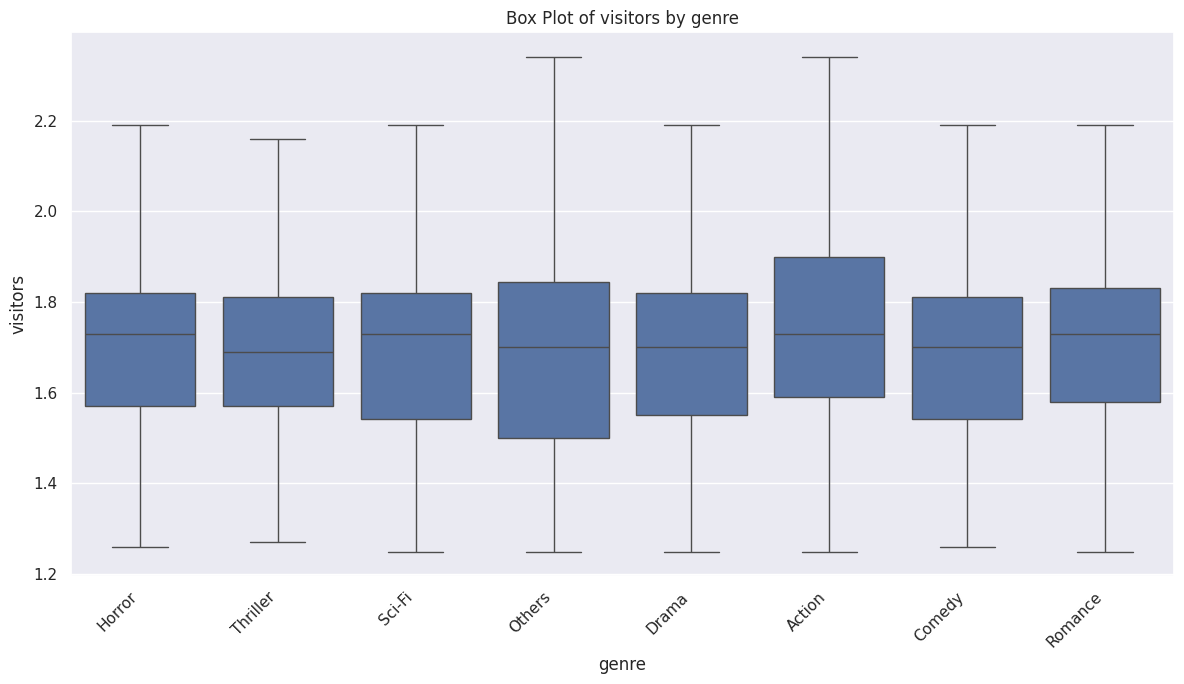

Analyzing relationship between genre and ad_impressions


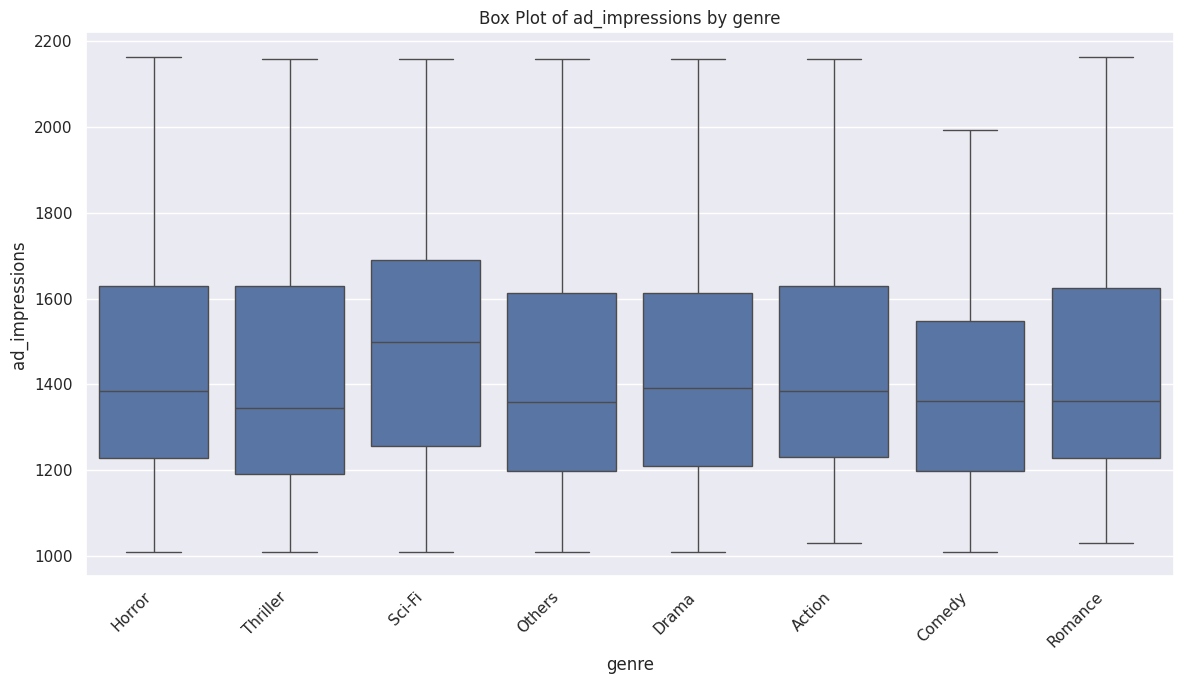

Analyzing relationship between genre and views_trailer


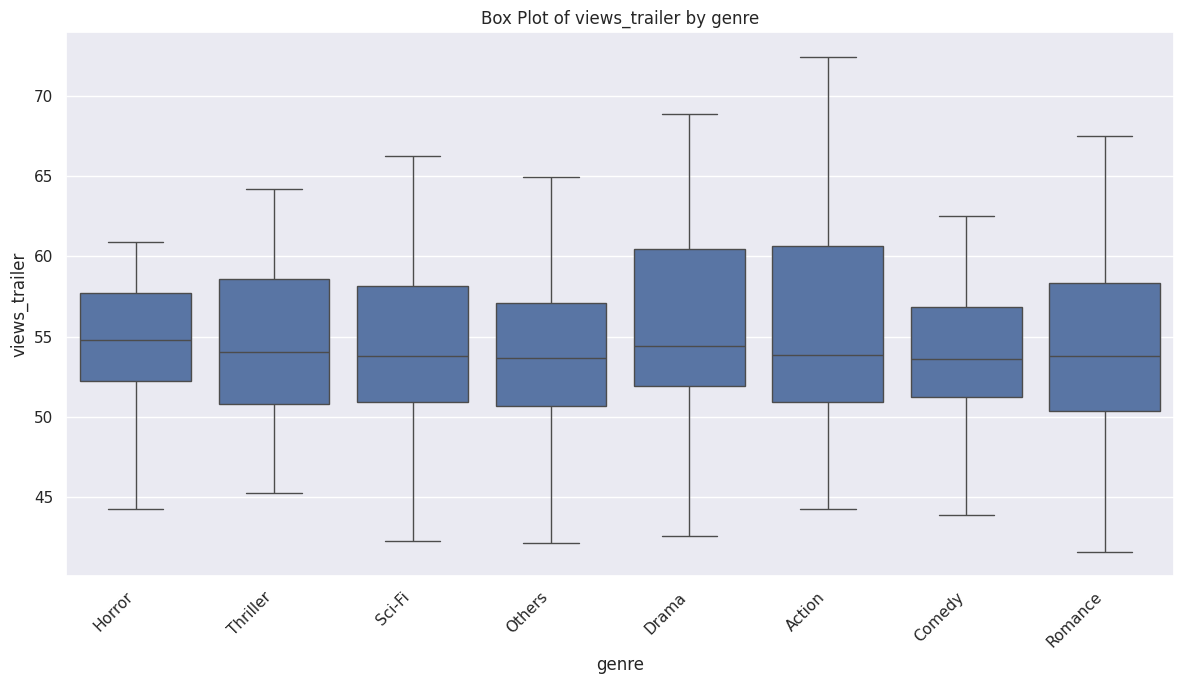

Analyzing relationship between genre and views_content


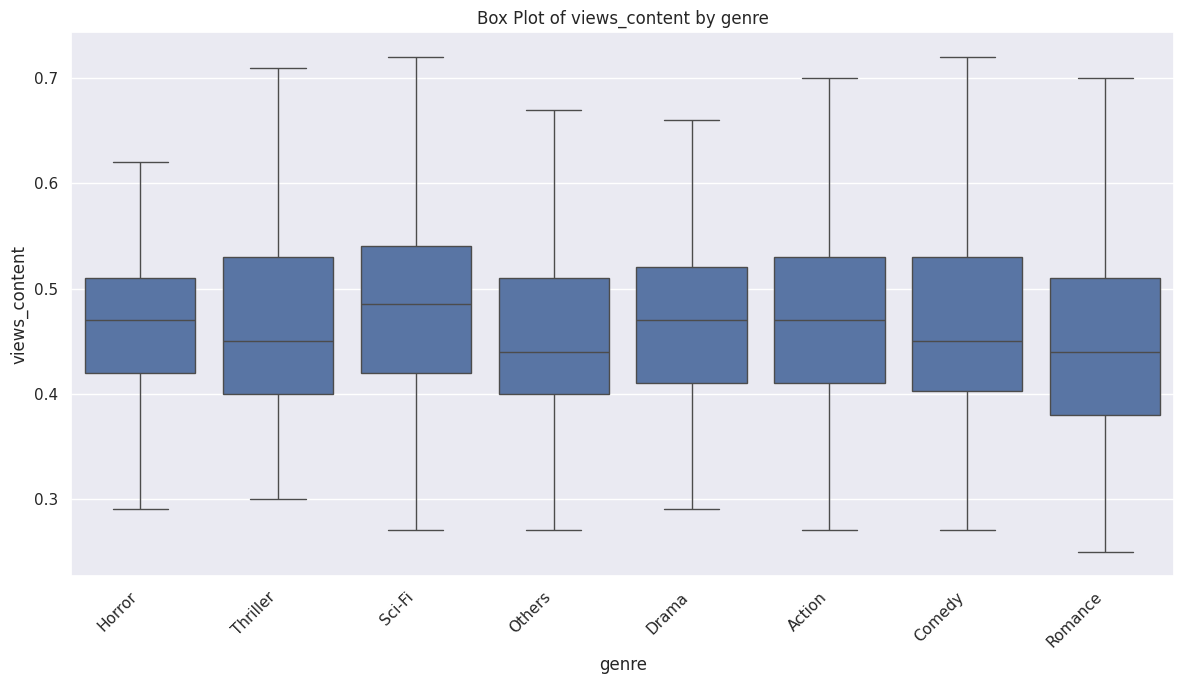

Analyzing relationship between dayofweek and visitors


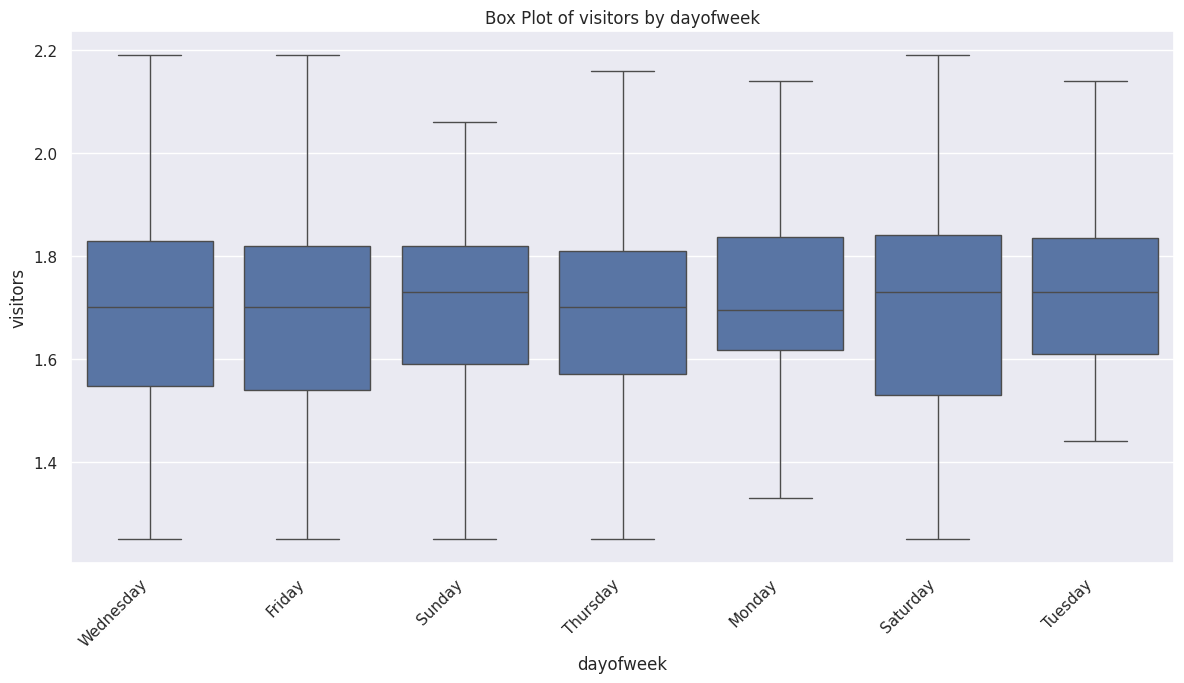

Analyzing relationship between dayofweek and ad_impressions


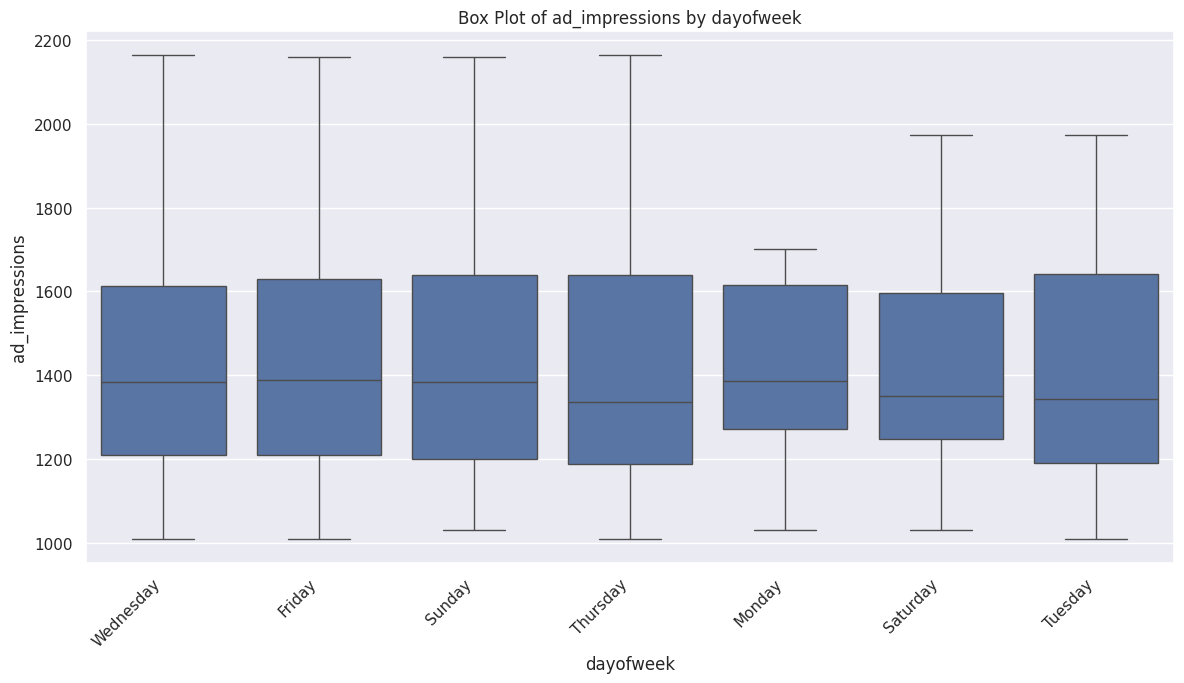

Analyzing relationship between dayofweek and views_trailer


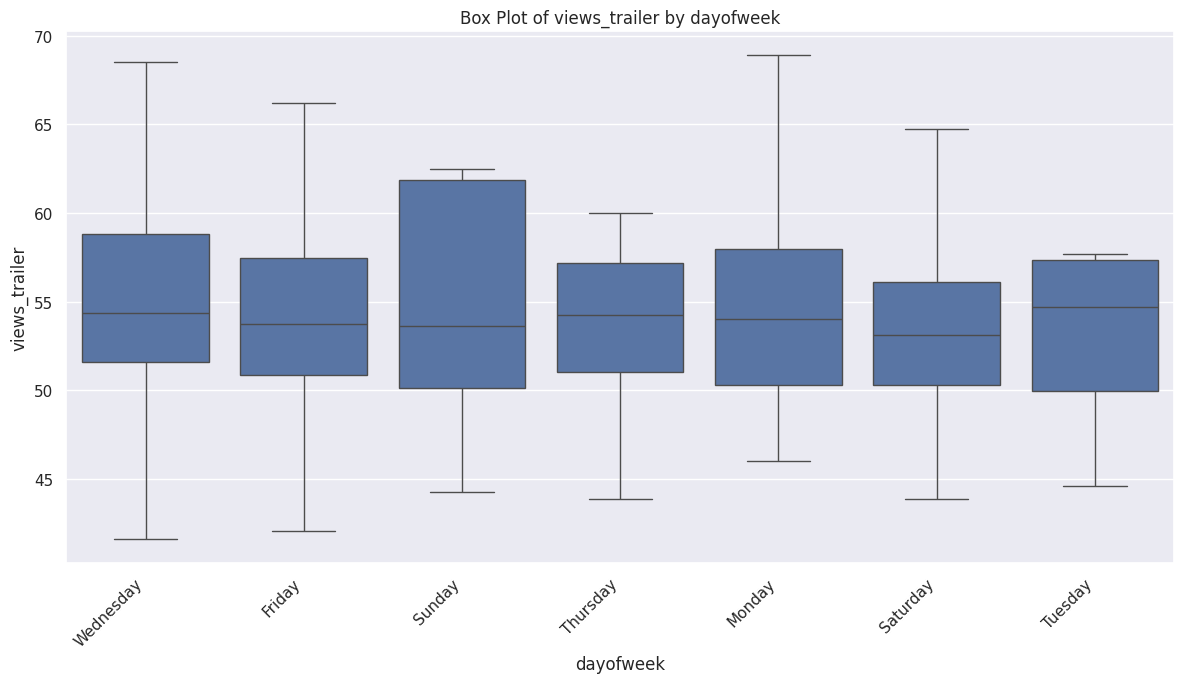

Analyzing relationship between dayofweek and views_content


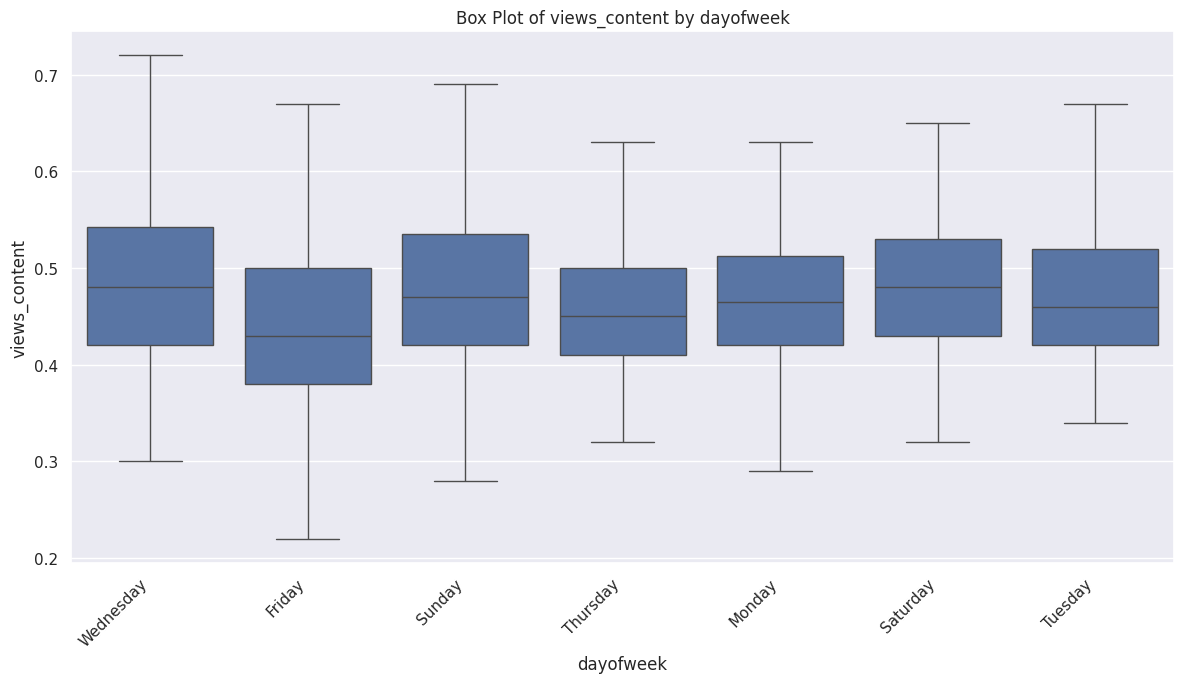

Analyzing relationship between season and visitors


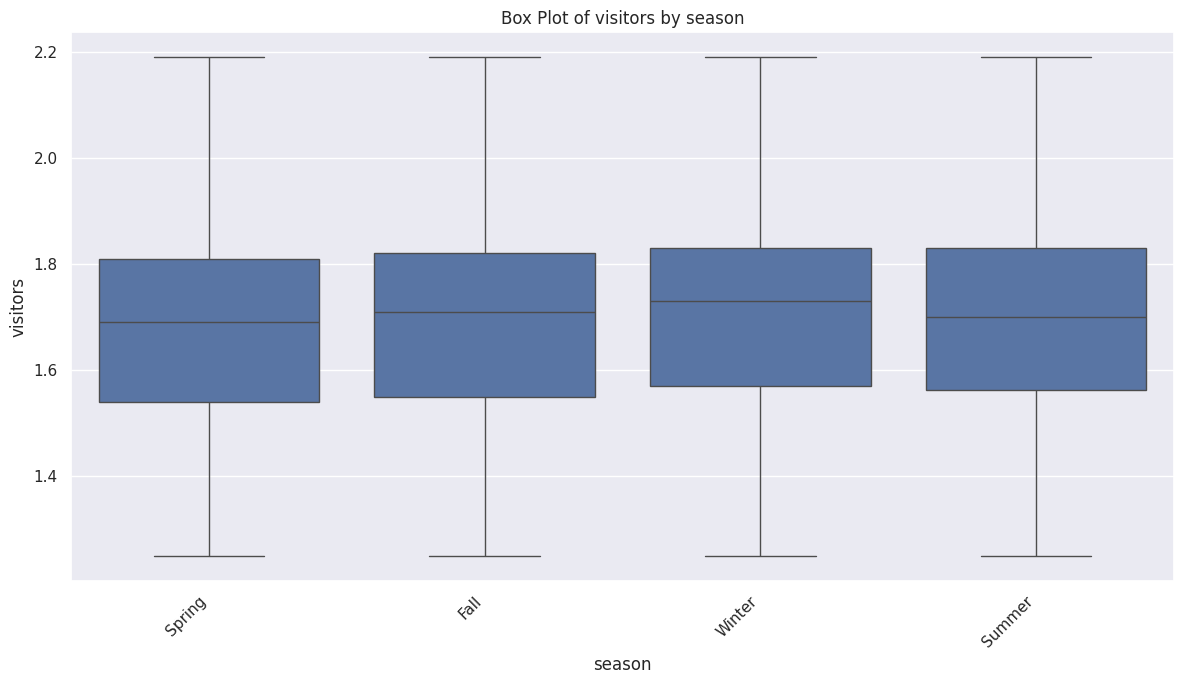

Analyzing relationship between season and ad_impressions


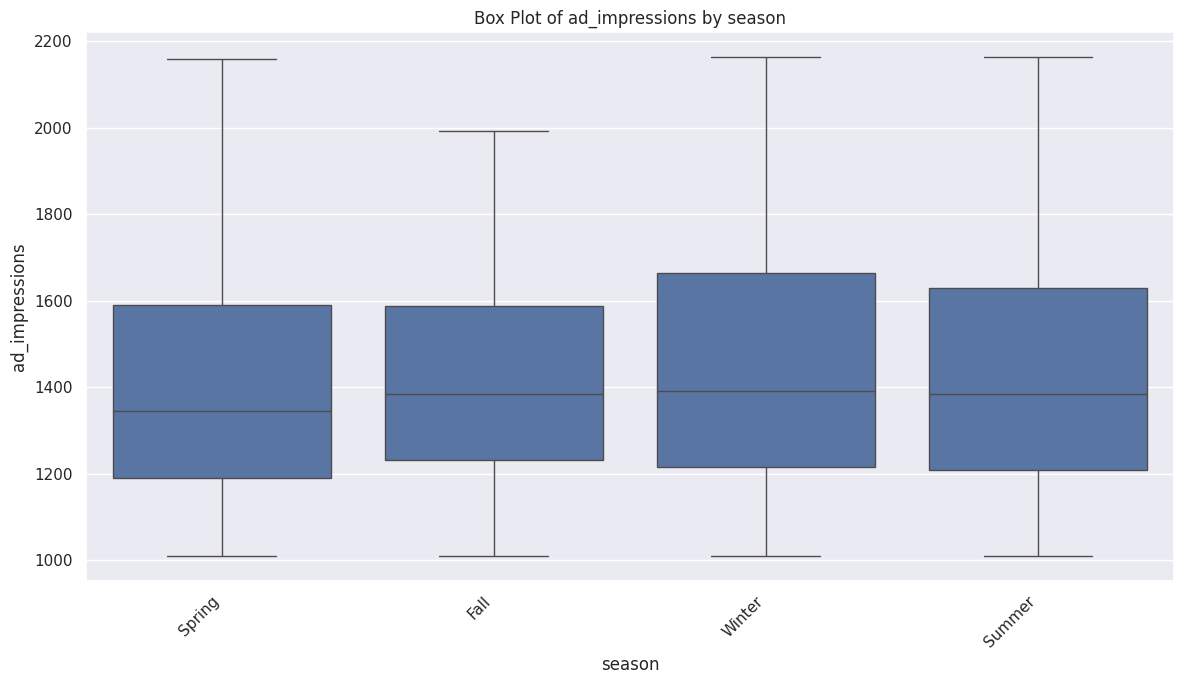

Analyzing relationship between season and views_trailer


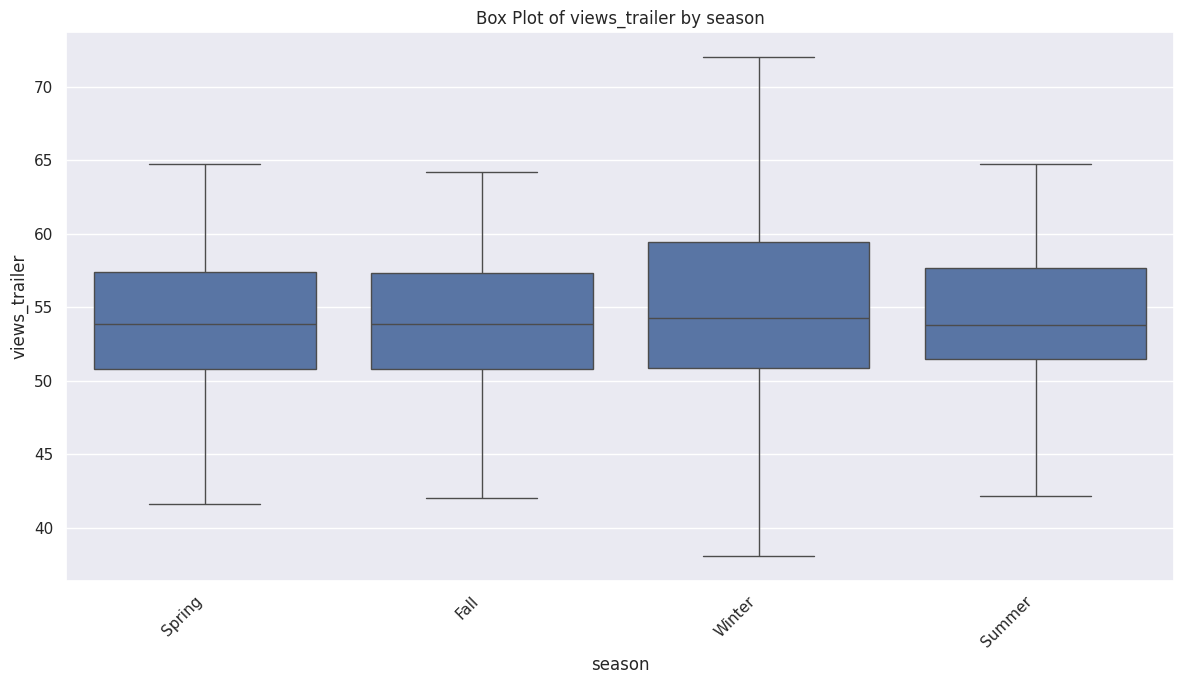

Analyzing relationship between season and views_content


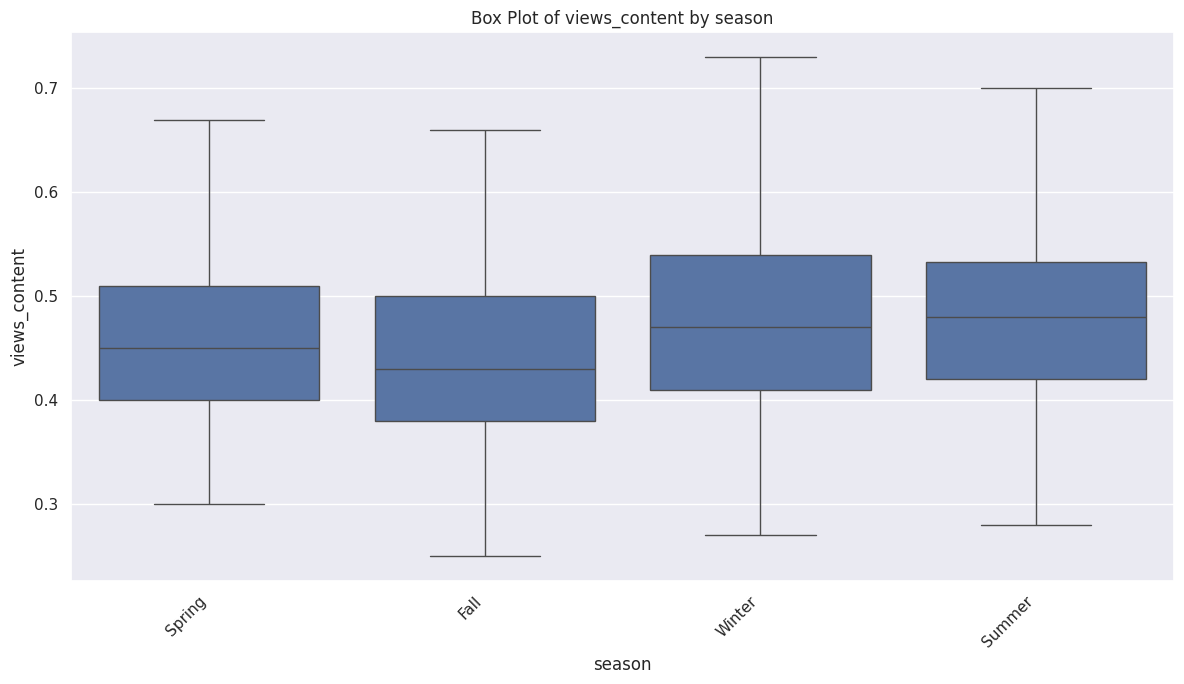

In [33]:
for cat_col in cat:
    for num_col in nums:
        print(f"Analyzing relationship between {cat_col} and {num_col}")
        bivariate_analyzer.plot_numerical_categorical(numerical_col=num_col, categorical_col=cat_col, kind='boxplot', figsize=(12, 7))


### Insights

## 1. views_content by major_sports_event
**Insight:**  
Content released on days with a **major_sports_event** (`value = 1`) tends to have slightly lower median first-day `views_content` compared to days without a major sports event (`value = 0`).  
This suggests that major sports events might divert audience attention, leading to a minor dip in content viewership.

---

## 2. views_content by genre
**Insight:**  
There are notable differences in first-day `views_content` across genres:  
- **Sci-Fi** and **Action** genres generally show higher median `views_content` and more high-performing outliers, indicating strong viewership potential.  
- **Horror** and **Thriller** also perform well, with competitive median views.  
- **Others** and **Romance** genres tend to have slightly lower median `views_content` and a narrower interquartile range, suggesting more consistent but less breakout performance.  
- **Comedy** and **Drama** fall in the mid-range in terms of median viewership.

---

## 3. views_content by dayofweek
**Insight:**  
The day of release significantly impacts first-day `views_content`:  
- **Friday** and **Saturday** generally exhibit the highest median `views_content`, with a wider spread, making them prime days for content release.  
- **Wednesday** also shows a relatively strong median, despite high release frequency.  
- **Monday**, **Tuesday**, and **Thursday** tend to have lower median `views_content` and tighter distributions, suggesting less variance in viewership.  
- **Sunday** views are moderate, often falling between weekdays and peak weekend days.

---

## 4. views_content by season
**Insight:**  
`views_content` shows some variation across seasons:  
- **Summer** and **Winter** generally have slightly higher median `views_content` compared to **Spring** and **Fall**.  
- Interquartile ranges and overall distributions across seasons are relatively similar, indicating that while seasonal preference exists, it is less pronounced than the impact of **dayofweek** or **genre**.
``


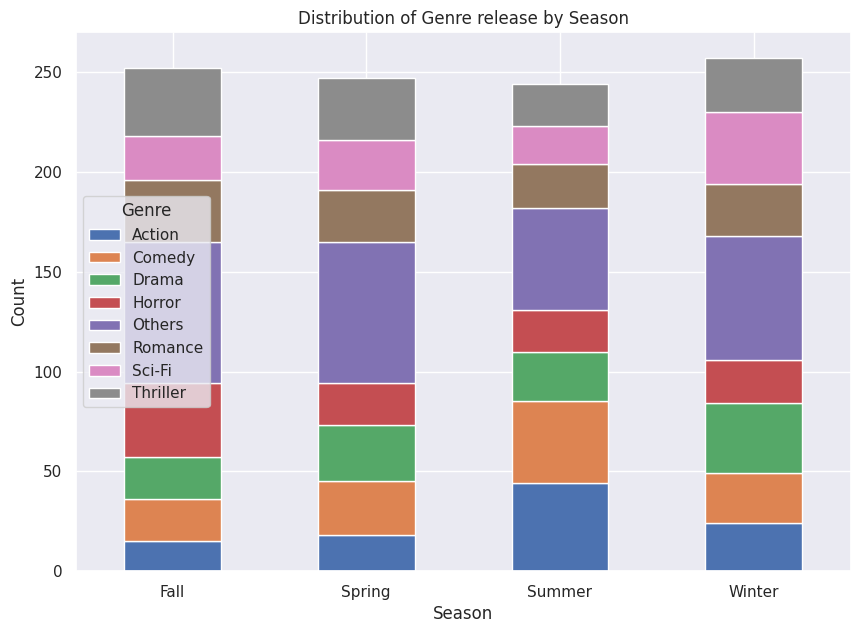

In [34]:
df100 = df.groupby(['season', 'genre']).size().unstack(fill_value=0)


# Plotting a stacked bar chart
ax = df100.plot(kind='bar', stacked=True, figsize=(10, 7))

plt.title('Distribution of Genre release by Season')
plt.xlabel('Season')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Genre')

# Add percentage labels to the bars


plt.show()

### Observations

*   **Overall Distribution:**  
    The **"Others"** genre consistently has the highest release count across all seasons.

*   **Summer Season:**
    *   **Action** and **Comedy** see a significant increase in releases, making Summer a dominant season for these genres.
    *   **Others** still leads, but **Action** and **Comedy** are notably higher compared to other seasons.

*   **Fall Season:**
    *   **Horror** and **Thriller** show a higher number of releases.
    *   **Others** remains strong.

*   **Winter Season:**
    *   **Drama** and **Sci‑Fi** have a relatively higher presence.
    *   **Others** continues to be prominent.

*   **Spring Season:**
    *   **Others** and **Comedy** are prominent.
    *   Other genres show a more **balanced distribution**.


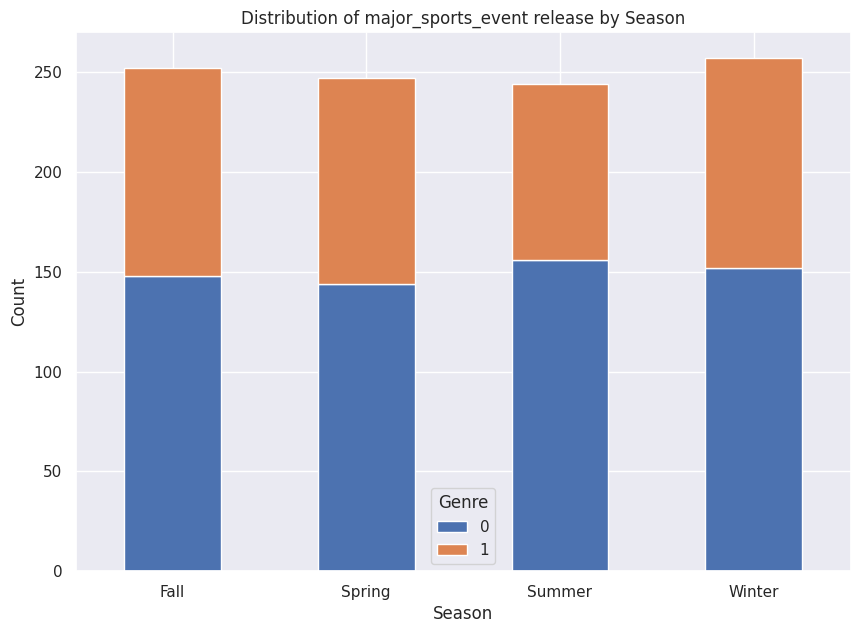

In [35]:
df100 = df.groupby(['season', 'major_sports_event']).size().unstack(fill_value=0)


# Plotting a stacked bar chart
ax = df100.plot(kind='bar', stacked=True, figsize=(10, 7))

plt.title('Distribution of major_sports_event release by Season')
plt.xlabel('Season')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Genre')

# Add percentage labels to the bars


plt.show()

In [36]:
df.columns

Index(['visitors', 'ad_impressions', 'major_sports_event', 'genre',
       'dayofweek', 'season', 'views_trailer', 'views_content'],
      dtype='object')

In [37]:

(df
 .pivot_table(index='dayofweek',
              aggfunc={'visitors':'mean',
                       'ad_impressions':'mean',
                       'views_trailer':'mean',
                       'views_content':'mean'})).style.highlight_max(color="green", axis=0)


,ad_impressions,views_content,views_trailer,visitors
dayofweek,,,,
Friday,1443.884065,0.446694,65.999566,1.704770
Monday,1410.471667,0.467917,62.680000,1.751667
Saturday,1435.818750,0.497955,62.818864,1.715227
Sunday,1443.720896,0.484179,69.039254,1.706716
Thursday,1425.113196,0.470619,67.447216,1.688041
Tuesday,1396.764348,0.487826,71.657826,1.749130
Wednesday,1429.592892,0.494608,68.413343,1.698584


In [38]:
(df
 .pivot_table(index='genre',
              aggfunc={'visitors':['min','max'],
                       'views_content':'mean',
                       'ad_impressions':'mean',
                       'views_trailer':'mean'})
 )


ad_impressions views_content views_trailer visitors      
                   mean          mean          mean      max   min
genre                                                             
Action      1456.161881      0.487327     71.224950     2.34  1.25
Comedy      1412.344035      0.474211     63.592368     2.34  1.26
Drama       1445.988624      0.473945     69.286330     2.34  1.25
Horror      1420.429901      0.481089     66.217426     2.34  1.26
Others      1414.903412      0.459765     62.445137     2.34  1.25
Romance     1429.083810      0.461238     67.690762     2.34  1.25
Sci-Fi      1505.773824      0.493235     71.201765     2.34  1.25
Thriller    1425.782655      0.476903     70.252655     2.34  1.27

In [39]:

(df
 .pivot_table(index='season',
              aggfunc={'visitors':['min','max'],
                       'views_content':'mean',
                       'ad_impressions':'mean',
                       'views_trailer':'mean'})
 )

ad_impressions views_content views_trailer visitors      
                 mean          mean          mean      max   min
season                                                          
Fall      1413.372937      0.445357     65.339127     2.34  1.25
Spring    1418.638300      0.467166     65.247571     2.19  1.25
Summer    1440.183197      0.496803     67.420861     2.34  1.25
Winter    1465.890856      0.484669     69.584786     2.34  1.25

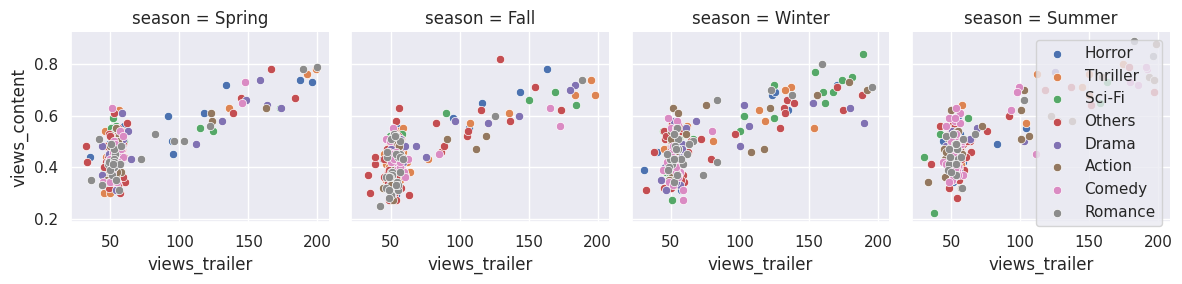

In [40]:
g = sns.FacetGrid(df, col="season", hue="genre", col_wrap=4)
g.map(sns.scatterplot, 'views_trailer', 'views_content')
plt.legend()
plt.show()

In [41]:
df.columns

Index(['visitors', 'ad_impressions', 'major_sports_event', 'genre',
       'dayofweek', 'season', 'views_trailer', 'views_content'],
      dtype='object')

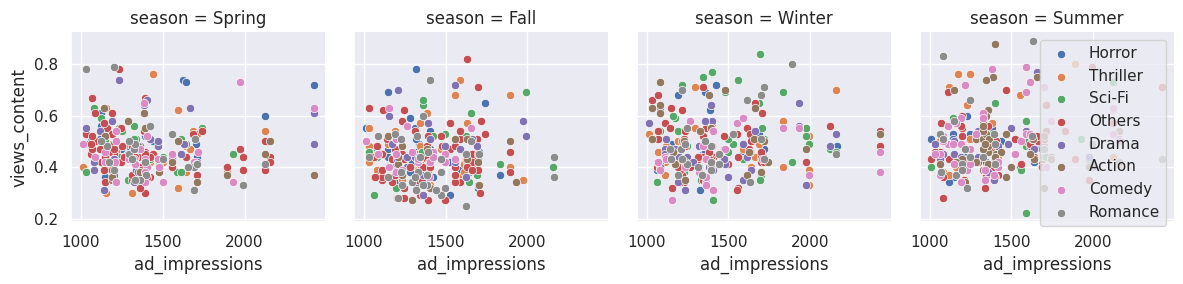

In [42]:
g = sns.FacetGrid(df, col="season", hue="genre", col_wrap=4)
g.map(sns.scatterplot, 'ad_impressions', 'views_content')
plt.legend()
plt.show()

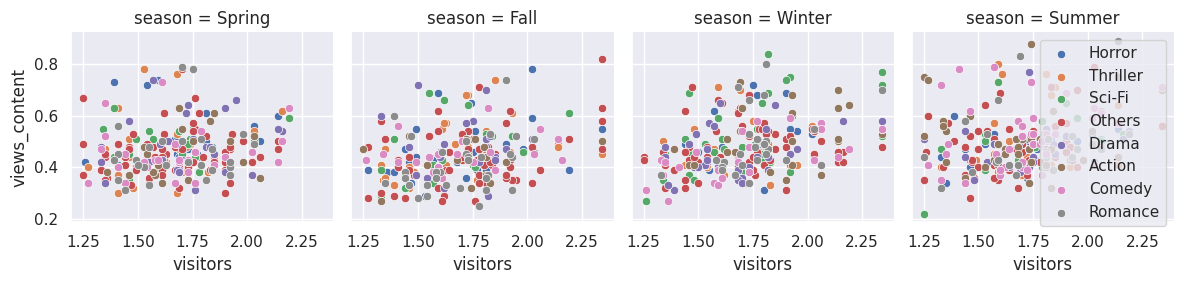

In [43]:
g = sns.FacetGrid(df, col="season", hue="genre", col_wrap=4)
g.map(sns.scatterplot, 'visitors', 'views_content')
plt.legend()
plt.show()

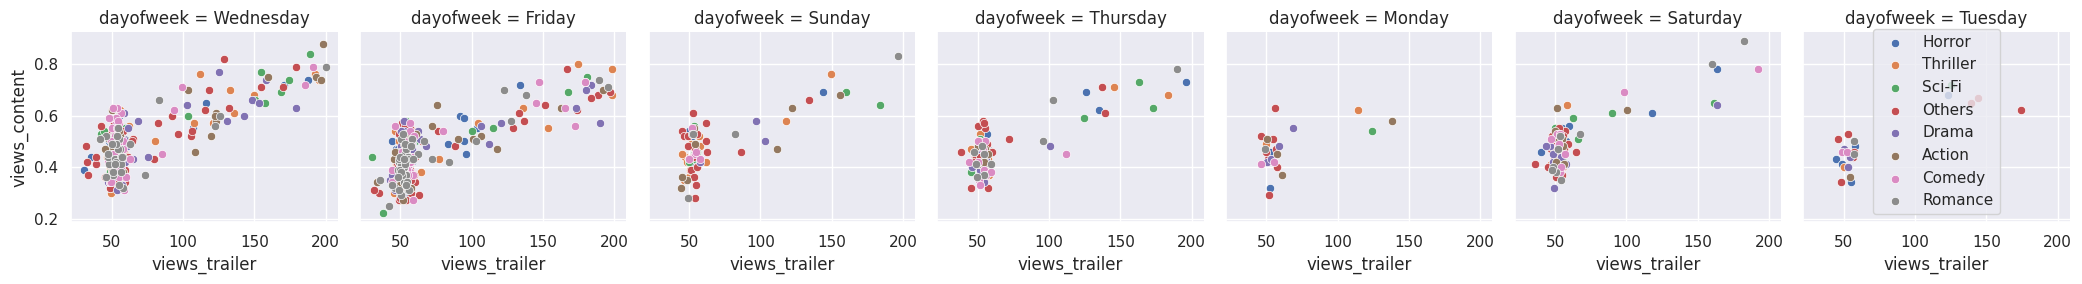

In [44]:
g = sns.FacetGrid(df, col="dayofweek", hue="genre", col_wrap=7)
g.map(sns.scatterplot, 'views_trailer', 'views_content')
plt.legend()
plt.show()

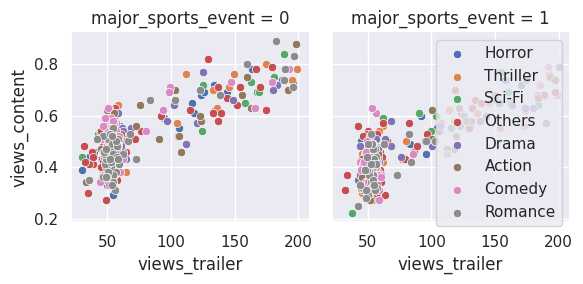

In [45]:
g = sns.FacetGrid(df, col="major_sports_event", hue="genre", col_wrap=2)
g.map(sns.scatterplot, 'views_trailer', 'views_content')
plt.legend()
plt.show()

## Inference from Bivariate analysis and insights of EDA

### Day-of-Week Performance
- **Highest First-Day Views (`views_content`)**: Saturday (0.497M) and Wednesday (0.495M).
- **Lowest**: Friday (0.447M), despite high release frequency.
- **Moderate**: Sunday (0.484M), Tuesday (0.488M), Thursday (0.471M), Monday (0.468M).
- **Trailer Views (`views_trailer`)**: Highest on Tuesday (71.66M), lowest on Monday (62.68M) and Saturday (62.82M).
- **Interesting Contrast**: Saturday has high content views despite low trailer views, suggesting unique audience behavior.
- **Ad Impressions**: Consistent across days (~1400–1440M), slight peak on Friday.
- **Visitors**: Stable (~1.69M–1.75M), minimal impact on daily view differences.

**Overall Insight**: Trailer views and content views show dynamic patterns, while ad impressions and visitors remain steady. Saturdays outperform despite low trailer engagement; Fridays underperform despite being popular release days.

---

### Genre Performance
- **Top Genres by First-Day Views**: Sci-Fi (0.493M), Action (0.487M), Horror (0.481M).
- **Lowest**: Others (0.460M), Romance (0.461M).
- **Trailer Views**: Sci-Fi and Action lead ~ 71M  Others and Comedy lowest (~62 to 63M) .

- **Ad Impressions**: Sci-Fi highest (1505M); others hover around 1412–1425M.
- **Visitors**: Consistent across genres (min ~1.25M, max ~2.34M).

**Overall Insight**: Sci-Fi and Action dominate both trailer and content views, likely supported by higher ad spend. Others and Romance lag, suggesting need for stronger promotion.

---

### Seasonal Performance
- **First-Day Views**: Summer highest (0.497M), Winter close (0.485M), Spring moderate (0.467M), Fall lowest (0.445M).
- **Trailer Views**: Winter leads (69.58M), Summer next (67.42M), Fall/Spring similar (~65M).
- **Ad Impressions**: Winter highest (1465M), Summer next (1440M), Fall/Spring lowest (~1413–1418M).
- **Visitors**: Range stable across seasons (min 1.25M, max ~2.34M).

**Overall Insight**: Summer and Winter are prime seasons for releases, showing higher engagement and ad spend. Fall underperforms across metrics, indicating seasonal audience behavior.

---

### Key Takeaways
- **Day Impact**: Saturdays and Wednesdays are best for releases; Fridays surprisingly weak. It could be visitors need news about release for a day to watch it on Weekend -> such context are more explained by Subject matter Experts.
- **Genre Impact**: Sci-Fi and Action outperform; Others and Romance need more marketing.
- **Seasonal Impact**: Summer and Winter are optimal; Fall is least favorable.
- **Marketing Insight**: Ad impressions and visitors remain steady, so trailer engagement and timing drive viewership differences.


# Data PreProcessing

## Outlier Treatment

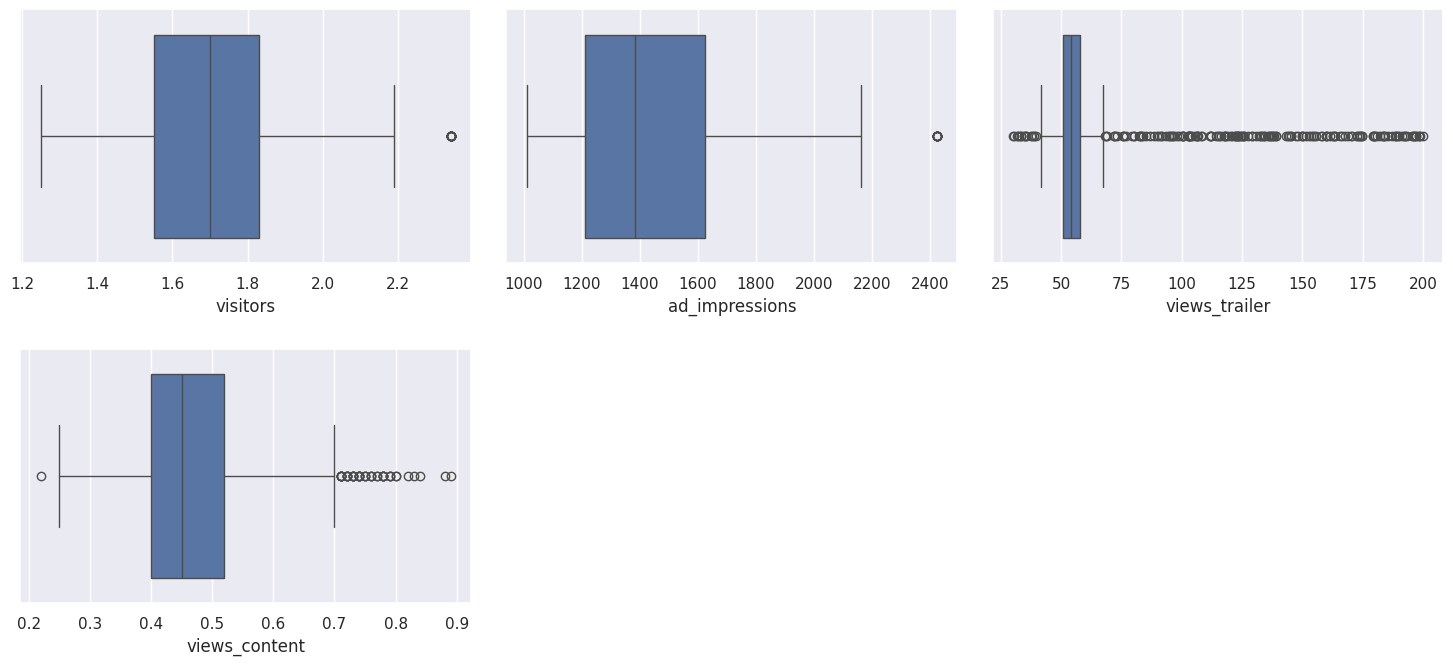

In [46]:
# outlier detection using boxplot
num_cols = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, 10))

for i, variable in enumerate(num_cols):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(data=df, x=variable)
    plt.tight_layout(pad=2)

plt.show()


**`views_trailer`** and **`views_content`** exhibit right skew with outlier values.  
However, these outliers represent legitimate data points, so **outlier treatment is not required**.


## Missing Value Treatment

In [47]:
analyzer.display_missing_values()


Missing Values:


,Count,Percentage


**No Missing Values**

## Duplicate value check

In [48]:
df.duplicated().sum()

np.int64(0)

**No Duplicate values**

In [49]:
df.columns

Index(['visitors', 'ad_impressions', 'major_sports_event', 'genre',
       'dayofweek', 'season', 'views_trailer', 'views_content'],
      dtype='object')

## Data Preparing for Model

### Steps to Build the Model

- **Predict Target:**  
  Our goal is to predict **`views_content`**.

- **Encode Categorical Fields:**  
  Convert categorical/object columns (e.g., `genre`, `season`, `dayofweek`, `major_sports_event`) into numerical representations using encoding techniques.

- **Split Data:**  
  Randomly split the dataset into **training** and **testing** samples to ensure unbiased evaluation.

- **Build and Validate Model:**  
  - Train a **Linear Regression** model using the training data.  
  - Validate model accuracy on the test data using appropriate metrics (e.g., R², RMSE).


In [50]:
# defining X and y variables
X = df.drop(["views_content"], axis=1)
y = df["views_content"]


In [51]:
# let's add the intercept to data
X = sm.add_constant(X)

In [52]:
display(X.head())

,const,visitors,ad_impressions,major_sports_event,genre,dayofweek,season,views_trailer
0,1.0,1.67,1113.81,0,Horror,Wednesday,Spring,56.70
1,1.0,1.46,1498.41,1,Thriller,Friday,Fall,52.69
2,1.0,1.47,1079.19,1,Thriller,Wednesday,Fall,48.74
3,1.0,1.85,1342.77,1,Sci-Fi,Friday,Fall,49.81
4,1.0,1.46,1498.41,0,Sci-Fi,Sunday,Winter,55.83


In [53]:
display(y.head())

,views_content
0,0.51
1,0.32
2,0.39
3,0.44
4,0.46


In [54]:
# creating dummy variables
X = pd.get_dummies(
    X,
    columns=X.select_dtypes(include=["object", "category"]).columns.tolist(),
    drop_first=True
)
X.head()

,const,visitors,ad_impressions,views_trailer,major_sports_event_1,genre_Comedy,genre_Drama,genre_Horror,genre_Others,genre_Romance,...,genre_Thriller,dayofweek_Monday,dayofweek_Saturday,dayofweek_Sunday,dayofweek_Thursday,dayofweek_Tuesday,dayofweek_Wednesday,season_Spring,season_Summer,season_Winter
0,1.0,1.67,1113.81,56.70,False,False,False,True,False,False,...,False,False,False,False,False,False,True,True,False,False
1,1.0,1.46,1498.41,52.69,True,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
2,1.0,1.47,1079.19,48.74,True,False,False,False,False,False,...,True,False,False,False,False,False,True,False,False,False
3,1.0,1.85,1342.77,49.81,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1.0,1.46,1498.41,55.83,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True


In [55]:
# converting the input attributes into float type for modeling
X = X.astype(float)
X.head()

,const,visitors,ad_impressions,views_trailer,major_sports_event_1,genre_Comedy,genre_Drama,genre_Horror,genre_Others,genre_Romance,...,genre_Thriller,dayofweek_Monday,dayofweek_Saturday,dayofweek_Sunday,dayofweek_Thursday,dayofweek_Tuesday,dayofweek_Wednesday,season_Spring,season_Summer,season_Winter
0,1.0,1.67,1113.81,56.70,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,1.0,1.46,1498.41,52.69,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,1.47,1079.19,48.74,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,1.0,1.85,1342.77,49.81,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,1.46,1498.41,55.83,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [56]:
# splitting the data in 70:30 ratio for train to test data

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [57]:
print("Number of rows in train data =", x_train.shape[0])
print("Number of rows in test data =", x_test.shape[0])

Number of rows in train data = 700
Number of rows in test data = 300


In [58]:
x_train.columns

Index(['const', 'visitors', 'ad_impressions', 'views_trailer',
       'major_sports_event_1', 'genre_Comedy', 'genre_Drama', 'genre_Horror',
       'genre_Others', 'genre_Romance', 'genre_Sci-Fi', 'genre_Thriller',
       'dayofweek_Monday', 'dayofweek_Saturday', 'dayofweek_Sunday',
       'dayofweek_Thursday', 'dayofweek_Tuesday', 'dayofweek_Wednesday',
       'season_Spring', 'season_Summer', 'season_Winter'],
      dtype='object')

# Model Building Linear Regression

## Build the model and comment on the model statistics

In [59]:
olsmodel = sm.OLS(y_train, x_train).fit()
pprint.pprint(olsmodel.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.792
Model:                            OLS   Adj. R-squared:                  0.785
Method:                 Least Squares   F-statistic:                     129.0
Date:                Sun, 28 Dec 2025   Prob (F-statistic):          1.32e-215
Time:                        01:16:26   Log-Likelihood:                 1124.6
No. Observations:                 700   AIC:                            -2207.
Df Residuals:                     679   BIC:                            -2112.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------


## Interpreting Regression Results

### 1. Overall Model Performance
- **R-squared:** 79.2% — The model explains a very strong proportion of variance in `views_content`.
- **Adjusted R-squared:** 78.5% — Remains high after accounting for predictors, indicating good generalization.
- **F-statistic & Prob (F-statistic):**  
  - F-statistic: 129.0  
  - p-value: 1.32e-215 (≈ 0)  
  This means the model is highly statistically significant; at least one predictor is useful.
- **Number of Observations:** 700 data points.

---

### 2. Coefficients and Significance (p < 0.05 indicates significance)

#### Highly Significant Predictors (p < 0.001)
- **visitors (Coeff: 0.1295):** Positive and strong predictor — more visitors → higher content views.
- **views_trailer (Coeff: 0.0023):** Strong positive predictor — higher trailer views → more content views.
- **major_sports_event_1 (Coeff: -0.0603):** Negative predictor — major sports events reduce content views.
- **dayofweek_Saturday, Sunday, Wednesday:** Highly significant positive predictors compared to baseline (likely Friday).
- **season_Spring, Summer, Winter:** All significant positive predictors compared to baseline season (likely Fall).

### Significant Predictors (p < 0.05)
- **const (Constant):** 0.0602 — Expected views when all predictors are zero.
- **dayofweek_Monday, Thursday:** Significant positive impact compared to baseline.

### Not Statistically Significant (p > 0.05)
- **ad_impressions:** p = 0.582 — Not a strong predictor when other factors are considered.
- **Genres (Comedy, Drama, Horror, Others, Romance, Sci-Fi, Thriller):** No significant difference from baseline genre.
- **dayofweek_Tuesday:** Marginally not significant (p = 0.096).

---

## 3. Model Diagnostics
- **Durbin-Watson:** 2.004 — No significant autocorrelation in residuals.


## Model Performance Check


### Model Performance Evaluation

Let's evaluate the model using multiple metrics.

#### Metrics from `scikit-learn`
- We will use built-in metric functions for:
  - **RMSE** (Root Mean Squared Error)
  - **MAE** (Mean Absolute Error)
  - **R²** (Coefficient of Determination)

#### Metrics
- We will define helper functions to compute:
  - **MAPE** (Mean Absolute Percentage Error):  
    Measures prediction accuracy as a percentage.
    **Note:** Works best when there are **no extreme values** and **no zeros** in the actuals.
  - **Adjusted R²**:  
    Adjusts R² for the number of predictors, providing a more reliable estimate of goodness-of-fit
  
    where \(n\) is the number of observations and \(p\) is the number of predictors.




In [60]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute MAPE
def mape_score(targets, predictions):
    return np.mean(np.abs(targets - predictions) / targets) * 100


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mape_score(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

In [61]:
# checking model performance on train set (seen 70% data)
print("Training Performance\n")
olsmodel_train_perf = model_performance_regression(olsmodel, x_train, y_train)
olsmodel_train_perf

Training Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.04853,0.038197,0.791616,0.785162,8.55644


In [62]:
# checking model performance on test set (seen 30% data)
print("Test Performance\n")
olsmodel_test_perf = model_performance_regression(olsmodel, x_test, y_test)
olsmodel_test_perf

Test Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.050603,0.040782,0.766447,0.748804,9.030464



## Model Performance Interpretation

We evaluate the model on both **training** and **test** sets using multiple metrics.

---

### Training Performance
| Metric            | Value      |
|-------------------|-----------:|
| RMSE             | 0.04853    |
| MAE              | 0.038197   |
| R-squared        | 0.791616   |
| Adjusted R²      | 0.785162   |
| MAPE (%)         | 8.55644    |

---

### Test Performance
| Metric            | Value      |
|-------------------|-----------:|
| RMSE             | 0.050603   |
| MAE              | 0.040782   |
| R-squared        | 0.766447   |
| Adjusted R²      | 0.748804   |
| MAPE (%)         | 9.030464   |

---

## Interpretation

### R-squared and Adjusted R-squared
- **Train:** 0.792 | **Test:** 0.766  
Both values are high, indicating the model explains a substantial proportion of variance in `views_content`.  
Adjusted R² values (0.785 train, 0.749 test) confirm strong generalization.

### RMSE (Root Mean Squared Error)
- **Train:** 0.04853 | **Test:** 0.050603  
Low RMSE values suggest small prediction errors, with minimal increase on test data.

### MAE (Mean Absolute Error)
- **Train:** 0.038197 | **Test:** 0.040782  
Indicates predictions are very close to actual values on average.

### MAPE (Mean Absolute Percentage Error)
- **Train:** 8.56% | **Test:** 9.03%  
A MAPE around 9% means predictions are within ~9% of actual values, which is very good.

---

## Conclusion
- **Good Fit:** High R² (76–79%) on both sets shows strong performance.
- **No Overfitting:** Metrics are consistent across train and test sets, indicating the model generalizes well.
- **Reliable Predictions:** Low RMSE, MAE, and MAPE confirm accurate and stable predictions for first-day content viewership.



# Testing the assumptions of linear regression model

## **Checking Linear Regression Assumptions**

Check the following Linear Regression assumptions:

1. **No Multicollinearity**

2. **Linearity of variables**

3. **Independence of error terms**

4. **Normality of error terms**

5. **No Heteroscedasticity**

### TEST FOR MULTICOLLINEARITY


# Multicollinearity and VIF

- **Multicollinearity** occurs when predictor variables in a regression model are highly correlated.  
  This is problematic because predictors should be independent; high correlation makes coefficients unreliable.

- **Detection Method:**  
  One common way to detect multicollinearity is using the **Variance Inflation Factor (VIF)**.

## Variance Inflation Factor (VIF)
- VIF measures how much the variance of a regression coefficient \( \beta_k \) is inflated due to correlation among predictors.
- If **VIF = 1**, there is no correlation with other predictors.
- Higher VIF indicates stronger multicollinearity.

### Rule of Thumb
- **VIF 1–5:** Low multicollinearity  
- **VIF 5–10:** Moderate multicollinearity  
- **VIF > 10:** High multicollinearity (problematic)


In [63]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def checking_vif(predictors):
    vif = pd.DataFrame()
    vif["feature"] = predictors.columns

    # calculating VIF for each feature
    vif["VIF"] = [
        variance_inflation_factor(predictors.values, i)
        for i in range(len(predictors.columns))
    ]
    return vif

In [64]:
checking_vif(x_train)

,feature,VIF
0,const,99.679317
1,visitors,1.027837
2,ad_impressions,1.029390
3,views_trailer,1.023551
4,major_sports_event_1,1.065689
5,genre_Comedy,1.917635
6,genre_Drama,1.926699
7,genre_Horror,1.904460
8,genre_Others,2.573779
9,genre_Romance,1.753525


**No multicollinearity is present among the variables as all VIF values are below 5**

### Dealing with high p-value variables


# Handling Insignificant Variables (p-value > 0.05)

- Some variables have **p-value > 0.05**, making them statistically insignificant.  
- Instead of dropping all at once (since p-values can change after removal), we will use an iterative approach:

## Process
1. Build the model and check p-values.
2. Drop the column with the **highest p-value**.
3. Rebuild the model without that feature and recheck p-values.
4. Repeat steps 2–3 until no columns have **p-value > 0.05**.




In [65]:
# initial list of columns
predictors = x_train.copy()
cols = predictors.columns.tolist()

# setting an initial max p-value
max_p_value = 1

while len(cols) > 0:
    # defining the train set
    x_train_aux = predictors[cols]

    # fitting the model
    model = sm.OLS(y_train, x_train_aux).fit()

    # getting the p-values and the maximum p-value
    p_values = model.pvalues
    max_p_value = max(p_values)

    # name of the variable with maximum p-value
    feature_with_p_max = p_values.idxmax()

    if max_p_value > 0.05:
        cols.remove(feature_with_p_max)
    else:
        break

selected_features = cols
print(selected_features)

['const', 'visitors', 'views_trailer', 'major_sports_event_1', 'dayofweek_Monday', 'dayofweek_Saturday', 'dayofweek_Sunday', 'dayofweek_Thursday', 'dayofweek_Wednesday', 'season_Spring', 'season_Summer', 'season_Winter']


In [66]:
x_train1 = x_train[selected_features]
x_test1 = x_test[selected_features]

In [67]:
olsmod1 = sm.OLS(y_train, x_train1).fit()
pprint.pprint(olsmod1.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.789
Model:                            OLS   Adj. R-squared:                  0.786
Method:                 Least Squares   F-statistic:                     233.8
Date:                Sun, 28 Dec 2025   Prob (F-statistic):          7.03e-224
Time:                        01:16:26   Log-Likelihood:                 1120.2
No. Observations:                 700   AIC:                            -2216.
Df Residuals:                     688   BIC:                            -2162.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------

In [68]:
# checking model performance on train set (seen 70% data)
print("Training Performance\n")
olsmod1_train_perf = model_performance_regression(olsmod1, x_train1, y_train)
olsmod1_train_perf

Training Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.048841,0.038385,0.788937,0.785251,8.595246


In [69]:
# checking model performance on test set (seen 30% data)
print("Test Performance\n")
olsmod1_test_perf = model_performance_regression(olsmod1, x_test1, y_test)
olsmod1_test_perf

Test Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.051109,0.041299,0.761753,0.751792,9.177097



### Model Performance After Removing Insignificant Features

## Training Performance
| Metric            | Value      |
|-------------------|-----------:|
| RMSE             | 0.048841   |
| MAE              | 0.038385   |
| R-squared        | 0.788937   |
| Adjusted R²      | 0.785251   |
| MAPE (%)         | 8.595246   |

## Test Performance
| Metric            | Value      |
|-------------------|-----------:|
| RMSE             | 0.051109   |
| MAE              | 0.041299   |
| R-squared        | 0.761753   |
| Adjusted R²      | 0.751792   |
| MAPE (%)         | 9.177097   |

---

## Interpretation and Comparison to Previous Model

### R-squared and Adjusted R²
- **New Model (olsmod1):** Train R² = 0.789, Test R² = 0.762 | Train Adj. R² = 0.785, Test Adj. R² = 0.752  
- **Previous Model (olsmodel):** Train R² = 0.792, Test R² = 0.766 | Train Adj. R² = 0.785, Test Adj. R² = 0.749  

**Observation:**  
Performance remains almost identical, with a slight improvement in test Adjusted R² (0.752 vs 0.749), suggesting better generalization after removing insignificant features.

### RMSE and MAE
- RMSE and MAE values remain low and comparable across both models, indicating stable predictive accuracy.

### MAPE
- MAPE is ~9% for both models, confirming predictions are within ~9% of actual values.

---

## Overall Conclusion
- **No Loss in Performance:** Metrics remain strong after feature removal.
- **Improved Parsimony:** The new model is simpler and slightly better at generalizing.
- **Stable and Reliable:** Consistent train/test metrics confirm robustness and no overfitting.

**Inference:**  
`olsmod1` (model with selected features) is preferred — simpler, equally accurate, and potentially better for unseen data.


**Now we'll check the rest of the assumptions on *olsmod2*.**

2. **Linearity of variables**

3. **Independence of error terms**

4. **Normality of error terms**

5. **No Heteroscedasticity**

### TEST FOR LINEARITY AND INDEPENDENCE

In [70]:
# let us create a dataframe with actual, fitted and residual values
df_pred = pd.DataFrame()

df_pred["Actual Values"] = y_train  # actual values
df_pred["Fitted Values"] = olsmod1.fittedvalues  # predicted values
df_pred["Residuals"] = olsmod1.resid  # residuals

df_pred.head()

,Actual Values,Fitted Values,Residuals
731,0.40,0.445434,-0.045434
716,0.70,0.677403,0.022597
640,0.42,0.433999,-0.013999
804,0.55,0.562030,-0.012030
737,0.59,0.547786,0.042214


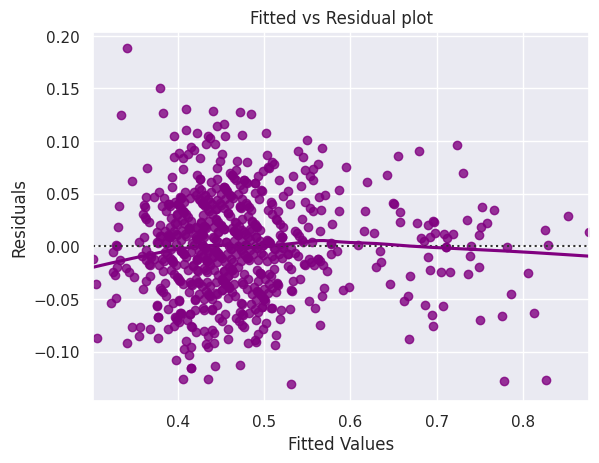

In [71]:
# plot the fitted values vs residuals

sns.residplot(
    data=df_pred, x="Fitted Values", y="Residuals", color="purple", lowess=True
)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Fitted vs Residual plot")
plt.show()


# Residual Analysis

- The scatter plot shows the distribution of **residuals (errors)** versus **fitted values (predicted values)**.

- If any pattern exists in this plot, it indicates **non-linearity** in the data, meaning the model does not fully capture non-linear effects.

- **Observation:**  
  No visible pattern in the plot → Assumptions of **linearity** and **independence** are satisfied.


### TEST FOR NORMALITY

**Why the test?**

* Error terms, or residuals, should be normally distributed. If the error terms are not normally distributed, confidence intervals of the coefficient estimates may become too wide or narrow. Once confidence interval becomes unstable, it leads to difficulty in estimating coefficients based on minimization of least squares. Non-normality suggests that there are a few unusual data points that must be studied closely to make a better model.

**How to check normality?**

* The shape of the histogram of residuals can give an initial idea about the normality.
* It can also be checked via a Q-Q plot of residuals. If the residuals follow a normal distribution, they will make a straight line plot, otherwise not.
* Other tests to check for normality includes the Shapiro-Wilk test.
    - Null hypothesis: Residuals are normally distributed
    - Alternate hypothesis: Residuals are not normally distributed

**How to fix if this assumption is not followed?**

* We can apply transformations like log, exponential, arcsinh, etc. as per our data.

**Prompt:** <font size=3 color="blue">Visualize the normality of residuals using a histogram with a kernel density estimate.</font>

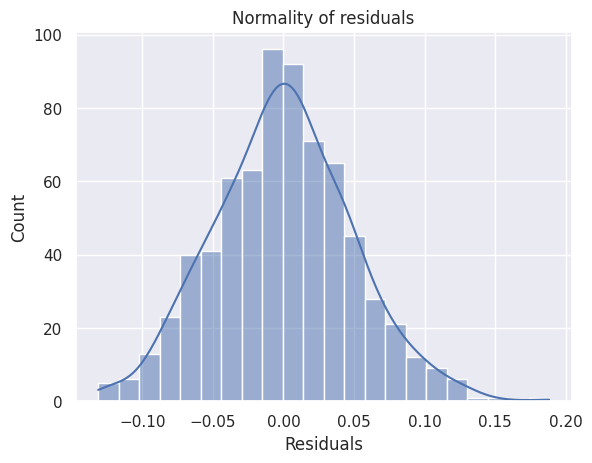

In [72]:
sns.histplot(data=df_pred, x="Residuals", kde=True)
plt.title("Normality of residuals")
plt.show()

- The histogram of residuals does have a bell shape.
- Let's check the Q-Q plot.

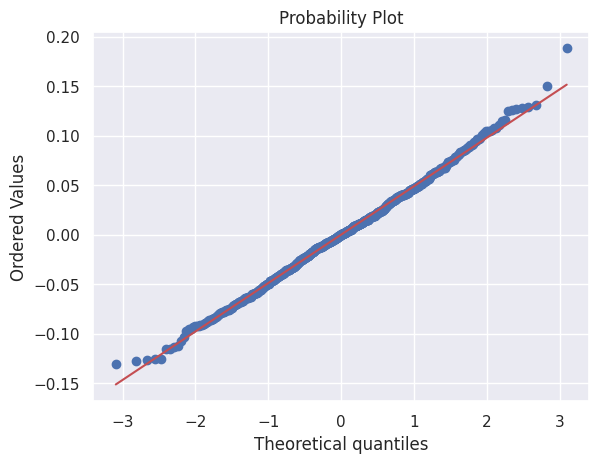

In [73]:
import pylab
import scipy.stats as stats

stats.probplot(df_pred["Residuals"], dist="norm", plot=pylab)
plt.show()

- The residuals more or less follow a straight line except for the tails.
- Let's check the results of the Shapiro-Wilk test.

In [74]:
stats.shapiro(df_pred["Residuals"])

ShapiroResult(statistic=np.float64(0.9973155427169242), pvalue=np.float64(0.31085896470071894))

**Since p-value > 0.05, the residuals are normal as per the Shapiro-Wilk test.**

### TEST FOR HOMOSCEDASTICITY

* **Homoscedascity**: If the variance of the residuals is symmetrically distributed across the regression line, then the data is said to be homoscedastic.

* **Heteroscedascity**: If the variance is unequal for the residuals across the regression line, then the data is said to be heteroscedastic.

**Why the test?**

* The presence of non-constant variance in the error terms results in heteroscedasticity. Generally, non-constant variance arises in presence of outliers.

**How to check for homoscedasticity?**

* The residual vs fitted values plot can be looked at to check for homoscedasticity. In the case of heteroscedasticity, the residuals can form an arrow shape or any other non-symmetrical shape.
* The goldfeldquandt test can also be used. If we get a p-value > 0.05 we can say that the residuals are homoscedastic. Otherwise, they are heteroscedastic.
    - Null hypothesis: Residuals are homoscedastic
    - Alternate hypothesis: Residuals have heteroscedasticity

**How to fix if this assumption is not followed?**

* Heteroscedasticity can be fixed by adding other important features or making transformations.

In [75]:
import statsmodels.stats.api as sms
from statsmodels.compat import lzip

name = ["F statistic", "p-value"]
test = sms.het_goldfeldquandt(df_pred["Residuals"], x_train1)
lzip(name, test)

[('F statistic', np.float64(1.1313612904200752)),
 ('p-value', np.float64(0.12853551819087372))]

**Since p-value > 0.05, we can say that the residuals are homoscedastic. So, this assumption is satisfied.**

# Model performance evaluation - Final Model

In [76]:
pred = olsmod1.predict(x_test1)

df_pred_test = pd.DataFrame({"Actual": y_test, "Predicted": pred})
df_pred_test.sample(10, random_state=1)

,Actual,Predicted
983,0.43,0.434802
194,0.51,0.500314
314,0.48,0.430257
429,0.41,0.492544
267,0.41,0.487034
746,0.68,0.680000
186,0.62,0.595078
964,0.48,0.503909
676,0.42,0.490313
320,0.58,0.560155


In [77]:
x_train_final = x_train1.copy()
x_test_final = x_test1.copy()

In [78]:
olsmodel_final = sm.OLS(y_train, x_train_final).fit()
print(olsmodel_final.summary())

                            OLS Regression Results                            
Dep. Variable:          views_content   R-squared:                       0.789
Model:                            OLS   Adj. R-squared:                  0.786
Method:                 Least Squares   F-statistic:                     233.8
Date:                Sun, 28 Dec 2025   Prob (F-statistic):          7.03e-224
Time:                        01:16:27   Log-Likelihood:                 1120.2
No. Observations:                 700   AIC:                            -2216.
Df Residuals:                     688   BIC:                            -2162.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.0747 

In [79]:
#checking model performance on train set (seen 70% data)
print("Training Performance\n")
olsmodel_final_train_perf = model_performance_regression(
    olsmodel_final, x_train_final, y_train
)
olsmodel_final_train_perf

Training Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.048841,0.038385,0.788937,0.785251,8.595246


In [80]:
# checking model performance on test set (seen 30% data)
print("Test Performance\n")
olsmodel_final_test_perf = model_performance_regression(
    olsmodel_final, x_test_final, y_test
)
olsmodel_final_test_perf

Test Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.051109,0.041299,0.761753,0.751792,9.177097


In [81]:
# Let us write the equation of linear regression
Equation = "views_content = "
print(Equation, end=" ")
for i in range(len(x_train_final.columns)):
    if i == 0:
        print(f"{olsmodel_final.params[i]:.4f}", end=" ")
    else:
        sign = "+" if olsmodel_final.params[i] >= 0 else "-"
        print(f"{sign} {abs(olsmodel_final.params[i]):.4f} * {x_train_final.columns[i]}", end=" ")
        if (i + 1) % 3 == 0:  # Break line after every 3 terms for better readability
            print("\n\t", end=" ")
print("\n")

views_content =  0.0747 + 0.1291 * visitors + 0.0023 * views_trailer 
	 - 0.0606 * major_sports_event_1 + 0.0321 * dayofweek_Monday + 0.0570 * dayofweek_Saturday 
	 + 0.0344 * dayofweek_Sunday + 0.0154 * dayofweek_Thursday + 0.0465 * dayofweek_Wednesday 
	 + 0.0226 * season_Spring + 0.0434 * season_Summer + 0.0282 * season_Winter 
	 



# Conclusion and Recommendations

## Business Insights

## Trailer Engagement is Key
- More trailer views (**views_trailer**) strongly predict higher first-day content views.
- Pre-release hype matters — invest in trailer marketing.

## Platform Activity Matters
- A larger number of platform visitors (**visitors**) leads to more first-day views.

## Timing is Crucial
- **Best Days:** Saturday, Wednesday, Sunday, Monday, Thursday.
- **Best Seasons:** Summer, Winter, Spring outperform Fall.
- Avoid releasing content during **major sports events** — they reduce viewership.

## Genre Impact
- Genre alone is not a strong predictor when other factors are considered.
- Success depends more on timing and trailer engagement than genre.

## Ad Impressions
- Ads were not a significant direct predictor in this model.
- Their impact may be indirect (e.g., boosting trailer views) or non-linear.

---

# Actionable Recommendations

### 1. Boost Trailer Marketing
- Create high-quality trailers and promote them aggressively.
- Use social media, influencers, and A/B testing to maximize engagement.

### 2. Optimize Release Schedule
- Focus major releases on **Saturday, Wednesday, Sunday**.
- Plan big launches for **Summer and Winter**.
- Avoid releasing during **major sports events**.

### 3. Grow Platform Engagement
- Improve user experience and retention to keep visitor numbers high.

### 4. Rethink Genre Strategy
- Don’t rely on genre popularity alone.
- Pair every genre with strong trailers and optimal release timing.

### 5. Reassess Ad Spend
- Analyze ad impact further before increasing budgets.
- Explore indirect effects and non-linear relationships with viewership.
